
# 08 Velocity Observer Bake Off

The servo has to know how fast its shaft is turning, and it has four ways to guess. It can
difference the potentiometer. It can rearrange the motor's electrical equation and work the
speed out from voltage and current. It can let the bridge float for a moment and read the
back-EMF straight off the terminals. Or it can count the commutation ripple in the current,
which is the most accurate of the lot and also the one the chip cannot afford.

Notebook 07 measured how noisy every channel is. This one spends that measurement. I score
each candidate against a speed reference that does not touch the pot at all, and then I work
out the blending weights from the measured noise instead of turning knobs until the plot
looks calm.

This notebook has been redone once. The first pass took its covariances from notebook 07
before 07 was corrected, and the pot noise it used was 6.6 times too big. The next section
says exactly what moved. The short version is that the corrected numbers make the verdict
stronger rather than weaker, which is not what I expected when I started redoing it.

If you are short on time, here is where it lands:

- The model based back-EMF estimate wins. A single unfiltered sample of it is already more
  than twice as quiet as a pot derivative taken over a 20 ms window, and averaging it over
  1 ms makes it nearly four times quieter still, at a twentieth of the lag.
- The six percent bias that estimate carried was two bookkeeping mistakes, not physics. Both
  are fixed here and it lands within a percent and a half of the reference.
- With the corrected covariances the pot deserves about one part in eighteen thousand of the
  velocity weight, and the firmware currently gives it all of it. That is the story behind
  $\hat\omega$ railing at rest.
- The shaft is not at rest when a rung opens. The capture tool seeked into the start band and
  started recording before anything settled, so every rung begins with a backward coast worth
  about -0.71 V of back-EMF. Taking that out of the resistance fit moves it from 3.99 to 4.18
  ohm, which is where the bare can measurement already was.
- The pot is quiet standing still and bad under drive, and those two facts do not fight each
  other. Its velocity error is a repeatable function of shaft position worth 14.5% rms, which
  is seven times its own sensor noise. I bin it by position here and the two halves of the
  captures land on top of each other with a correlation of 0.997.

## Picking a rig

Everything below reads one dataset, and the dataset's manifest names the board and the servo
it came off. So the shunt value, the divider ratio and the gear ratio all travel with the
captures rather than living in my head.

Two tables print. The first is what the hardware is. The second is what somebody measured
when they looked, with a bracket and a source on every entry.

2S is the primary supply for every number here. USB droops under load, so a fit against duty
on USB quietly folds rail droop into the duty axis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch, detrend, butter, filtfilt, hilbert

import oscnb

ds = oscnb.use("sg90-a__dev-v006-D__2s")
board, servo = oscnb.current().board, oscnb.current().servo

FS = board.tick_hz                                    # 20 kHz, one telemetry sample per tick
DT = 1.0 / FS
GEAR = servo.measured["gear_ratio_measured"].value    # 234.73:1, counted teeth, exact
KE = servo.measured["ke_measured"].value / 1e3        # V per motor rev/s, from the registry
PPR = servo.measured["ripple_order_measured"].value   # 6 current spikes per motor revolution

dataset  sg90-a__dev-v006-D__2s
supply   2s
rig      SG90 clone, unit A on osc-dev-v006 board D (bodged toward rev-2A)



,captures,recordings per capture,names
experiment,,,
breakaway,5,1,sweep
bridge,5,3,"fast, slow, spindown"
grid,10,1,sweep
reversal,5,1,sweep
ripple,5,1,sweep
stepcoast,5,5,"step120, step20, step40, step60, step80"



derived constants (what the hardware is)


value
where            quantity                                           unit                         
board            converter step                                     mV per count           0.8057
                 terminal divider ratio r                                                  3.0606
                 terminal difference                                mV per count           2.4658
                 terminal bias VB                                   mV                   627.9352
                                                                    counts               779.4008
                 driven-low terminal reads                          counts               524.7451
                 motor current                                      mA per count           0.8952
                                                                    counts per A        1117.0909
                 shunt                                              mOhm                  60.0000
                 amplifier gain                                     x                     15.0000
                 rail tap ratio                                                            2.5000
                 sample rate                                        samples per ms        20.0000
                 current settled from (UNVERIFIED)                  % duty                13.3333
                 voltage settled from (UNVERIFIED)                  % duty                13.3333
servo            pot intercept                                      counts               232.0000
                 pot slope                                          counts per degree     19.9600
                 envelope low                                       counts (10 deg)      431.6000
                 envelope high                                      counts (170 deg)    3625.2000
                 runway                                             counts              3193.6000
                 seek guard low                                     counts               432.0000
                 seek guard high                                    counts              3625.0000
servo (measured) gear_ratio_measured [234.73, 234.73] mechanical... :1                   234.7300
                 ripple_order_measured [6, 6] bringup isns-diff ... per motor rev          6.0000
                 kv_measured [7880, 8040] bringup isns-diff run28   RPM/V               7960.0000
                 kt_measured [1.19, 1.21] bringup isns-diff run28   mN-m/A                 1.2000
                 r_motor_measured [4.16, 4.24] bringup isns-diff... Ohm                    4.2000
                 l_motor_measured [0.45, 0.55] bringup isns-diff... mH                     0.5000
                 stall_current_measured [1.45, 1.55] bringup isn... A                      1.5000
                 stall_torque_measured [1.75, 1.85] bringup isns... mN-m                   1.8000
                 free_run_current_measured [0.078, 0.084] bringu... A                      0.0810
                 r_winding_measured [4.3, 4.8] nb03, full duty o... Ohm                    4.5000
                 pot_scale_measured [19.3, 19.43] nb06 sec 5.5, ... counts/deg            19.3000
                 coast_bemf_slope_measured [0.19, 0.204] nb01, c... V per wiper V/s        0.1970
                 ke_measured [7.44, 7.73] nb03 route R: ripple s... mV per motor rev/s     7.5840


measured values (what someone found when they looked)


value                 unit           bracket  \
where quantity                                                            
board vb_bias            781.000               counts        [775, 783]   
      rail_droop_usb      -3.500  % over 20-100% duty          [-4, -3]   
      opa_noise_floor      2.200           counts RMS          [2, 2.4]   
      esd_clamp_skew       1.800               V bemf        [1.7, 1.9]   
servo gear_ratio         234.730                   :1  [234.73, 234.73]   
      ripple_order         6.000        per motor rev            [6, 6]   
      kv                7960.000                RPM/V      [7880, 8040]   
      kt                   1.200               mN-m/A      [1.19, 1.21]   
      r_motor              4.200                  Ohm      [4.16, 4.24]   
      l_motor              0.500                   mH      [0.45, 0.55]   
      stall_current        1.500                    A      [1.45, 1.55]   
      stall_torque         1.800                 mN-m      [1.75, 1.85]   
      free_run_current     0.081                    A    [0.078, 0.084]   
      r_winding            4.500                  Ohm        [4.3, 4.8]   
      pot_scale           19.300           counts/deg     [19.3, 19.43]   
      coast_bemf_slope     0.197      V per wiper V/s     [0.19, 0.204]   
      ke                   7.584   mV per motor rev/s      [7.44, 7.73]   

                                                                   source  \
where quantity                                                              
board vb_bias                     Hi-Z rest baseline, 2S grid + stepcoast   
      rail_droop_usb                      2S vs USB grid, 5 captures each   
      opa_noise_floor                             bringup isns-diff run29   
      esd_clamp_skew                           bringup isns-diff findings   
servo gear_ratio                          mechanical/sg90/measurements.py   
      ripple_order                           bringup isns-diff runs 25-27   
      kv                                          bringup isns-diff run28   
      kt                                          bringup isns-diff run28   
      r_motor                                     bringup isns-diff run28   
      l_motor                                     bringup isns-diff run28   
      stall_current                               bringup isns-diff run28   
      stall_torque                                bringup isns-diff run28   
      free_run_current                            bringup isns-diff run28   
      r_winding                              nb03, full duty onset anchor   
      pot_scale         nb06 sec 5.5, travel-weighted ripple cycle cou...   
      coast_bemf_slope                                      nb01, chain 2   
      ke                nb03 route R: ripple speed + coast BEMF over 2...   

                                                                   caveat  
where quantity                                                             
board vb_bias           nominal 779 from the 200/47 network, so 0.3%. ...  
      rail_droop_usb    USB also dips -21.8% transiently at 0.76 A; 2S...  
      opa_noise_floor   arm-B external network at G15; the internal PG...  
      esd_clamp_skew    above this the A-side ESD clamp skews the divi...  
servo gear_ratio        (47*38*32*23)/(10*10*8*7), counted teeth on th...  
      ripple_order      3-segment commutator x 2 brushes; optical tach...  
      kv                bare can, +/-1% HSI scale; pinion stayed on th...  
      kt                                                                   
      r_motor           bare can. nb03 got 4.5 [4.3, 4.8] in-servo via...  
      l_motor                            locked-rotor burst, tau_e 102 us  
      stall_current                                       = V/R confirmed  
      stall_torque                                                         
      free_run_current                                         at duty 65


## A correction from notebook 07

Before anything else, the number this whole notebook is built on.

Notebook 07 measures the noise of every channel over the one second zero-duty baseline that
opens each capture. Its first version took the standard deviation over the whole second, and
the whole second is not all noise. The burst opens with the shaft ringing down from the seek
that put it there, and that ring-down runs about 200 ms. It is mechanical motion, not sensor
noise, and it lands in the standard deviation of every channel that can see the shaft.

The current channel is the tell. Current has no mechanical term in it at all, so if the head
of the baseline were noise then dropping it would move the current channel too. It does not
move. Everything else that moves was measuring the shaft settling.

I ran this notebook once on the uncorrected table. Here is the size of the mistake, and from
here on every number uses the settled figures.

In [2]:

SETTLE = 4000            # samples to drop at the head of a baseline burst, 200 ms at 20 kHz
NOISE_CH = ("pos", "current_raw", "current_trough", "vmotor_a", "vmotor_b")


def rest_sd(cut):
    # Standard deviation of each channel over the zero-duty baseline, averaged over the ten
    # grid captures. `cut` is how many samples to throw away at the head of the burst.
    return {ch: float(np.mean([ds.read("grid", c, "sweep")
                                 .pipe(lambda d: d[d.cmd_duty_q15 == 0])[ch].values[cut:].std()
                               for c in ds.captures("grid")]))
            for ch in NOISE_CH}


SD_RAW = rest_sd(0)             # whole baseline, what notebook 07 published first
SD_REST = rest_sd(SETTLE)       # settling head dropped, what notebook 07 carries now

NOISE = pd.DataFrame({"whole second": SD_RAW, "after 200 ms": SD_REST})
NOISE["inflation"] = NOISE["whole second"] / NOISE["after 200 ms"]
NOISE.index.name = "channel (ADC counts)"
print("rest noise, mean over the ten 2S grid captures\n")
print(NOISE.round(3).to_string())
print(f"\nthe current channel moves by {100 * (NOISE.loc['current_raw', 'inflation'] - 1):+.1f}%"
      f" between the two windows. That is the control. Everything else in the inflation column"
      f"\nwas the shaft settling, not the sensor.")

rest noise, mean over the ten 2S grid captures

                      whole second  after 200 ms  inflation
channel (ADC counts)                                       
pos                          8.040         1.207      6.663
current_raw                  1.031         1.032      0.999
current_trough               1.107         1.108      0.999
vmotor_a                    15.772         0.652     24.190
vmotor_b                    21.986         0.731     30.057

the current channel moves by -0.1% between the two windows. That is the control. Everything else in the inflation column
was the shaft settling, not the sensor.



## What counts as truth

I need a speed reference that is better than everything I am scoring, and it cannot be the
pot. Notebook 06 showed the pot's local gain swinging by a factor of 5.8 across the travel,
and the Ke closure showed that using pot speed as the reference throws the answer off by 13
to 28 percent with a spread of 26 percent. Against the ripple line the same measurement has
a spread of 1.9 percent. So the pot is a thing being scored, never the scorer.

The reference is the commutation ripple. A brushed can with three segments and two brushes
puts six current spikes into the shunt per motor revolution, so the frequency of that line
divided by six is the motor speed. Two rules from notebook 06 and the ripple work, both of
which I follow here and neither of which I re-derive.

1. Search only 1400 to 5200 Hz. A bare peak search starting at DC locks onto a subharmonic
   and hands back a clean looking answer that is an integer fraction of the truth.
2. Stay between 30 and 45 percent duty. Below that the line falls out of the search band.
   Above about 50 percent a three per revolution subharmonic takes over.

I use the line two ways. Averaged over a whole rung it gives one very solid number. Band
passed and run through a Hilbert transform it gives speed as a function of time inside the
rung, which is what lets me score an estimator sample by sample instead of rung by rung.

In [3]:
def line_hz(x, lo=1400.0, hi=5200.0, nperseg=4096):
    """
    Frequency of the commutation line. Welch spectrum, peak inside the allowed band only,
    then a parabolic fit through the peak bin and its two neighbours so the answer is not
    quantised to the bin spacing (4.9 Hz at nperseg 4096, which is 0.2% at 2 kHz).
    """
    x = detrend(np.asarray(x, float))
    f, P = welch(x, fs=FS, nperseg=min(nperseg, len(x)))
    m = (f > lo) & (f < hi)
    fm, Pm = f[m], P[m]
    i = int(np.argmax(Pm))
    if 0 < i < len(fm) - 1:                       # log-parabola vertex, standard peak interp
        a, b, c = np.log(Pm[i - 1]), np.log(Pm[i]), np.log(Pm[i + 1])
        return fm[i] + 0.5 * (a - c) / (a - 2 * b + c) * (fm[1] - fm[0])
    return fm[i]


def ripple_speed(x, f0=None, bw=0.30, smooth=200):
    """
    Motor speed in revolutions per second, sample by sample.

    Band pass the current around the line, take the analytic signal, unwrap its phase, and
    differentiate. Phase accumulates at 2*pi*f per second and there are PPR cycles per motor
    revolution, so the derivative divided by 2*pi*PPR is revolutions per second. The 10 ms
    smoothing window is what keeps the phase derivative from being dominated by the noise
    riding on the line itself.
    """
    x = detrend(np.asarray(x, float))
    f0 = f0 if f0 is not None else line_hz(x)
    b, a = butter(3, [f0 * (1 - bw) / (FS / 2), f0 * (1 + bw) / (FS / 2)], btype="band")
    ph = np.unwrap(np.angle(hilbert(filtfilt(b, a, x))))
    w = smooth
    out = np.full(len(ph), np.nan)
    out[w // 2:len(ph) - w + w // 2] = (ph[w:] - ph[:-w]) / (w * DT) / (2 * np.pi * PPR)
    return out


def rungs(dataset, experiment="grid", duties=(30, 35, 40, 45), recording="sweep"):
    """Every drive segment at one of the listed duties, both directions, all captures."""
    for cap in dataset.captures(experiment):
        df = dataset.read(experiment, cap, recording)
        # every capture opens with a one second zero-duty baseline. That is the current
        # channel's own bias reading, and it belongs to this capture, not to the board.
        bias = df[df.cmd_duty_q15 == 0].current_raw.mean()
        for seg, g in df.groupby("seg"):
            duty = round(abs(int(g.cmd_duty_q15.iloc[0])) / 32767 * 100)
            if duties is not None and duty not in duties:
                continue
            yield cap, duty, bias, g.sort_values("tick")

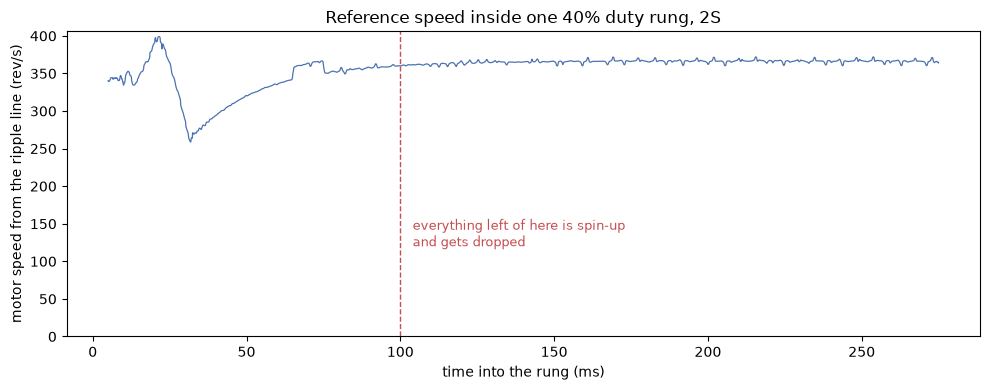

In [4]:
# One rung, start to finish, with the ripple reference tracking through it.
g = next(g for cap, d, b, g in rungs(ds, duties=(40,)) if int(g.dir.iloc[0]) == 1)
sp = ripple_speed(g.current_raw.values)
t = g.tick.values * DT * 1e3

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t, sp, lw=0.9, color="#4c72b0")
ax.axvline(100, color="#c44e52", ls="--", lw=1)
ax.text(104, 120, "everything left of here is spin-up\nand gets dropped", fontsize=9, color="#c44e52")
ax.set_xlabel("time into the rung (ms)")
ax.set_ylabel("motor speed from the ripple line (rev/s)")
ax.set_title("Reference speed inside one 40% duty rung, 2S")
ax.set_ylim(0, None)
plt.tight_layout(); plt.show()

**What you are looking at:** the motor's speed through a single rung, measured from the
commutation ripple and nothing else. The shaft takes about 80 ms to get up to speed and then
holds flat for the remaining 180 ms.

That spin-up is the first thing that has to be dealt with, and it caused one of the two
errors I found. A rung average taken over the whole window is not an average of the steady
speed, and more importantly the current during spin-up is much larger than the settled
current. At 40 percent duty the whole-rung mean current is 0.142 A while the settled mean is
0.092 A. Averaging one against the other pairs a nearly settled speed with a badly inflated
current. From here on every rung drops its first 100 ms.

## The candidates

All four estimate the same thing, the motor shaft speed $\omega_m$ in revolutions per second.

**(a) and (b), the pot derivative.** Difference the position channel over a window of $W$
ticks and scale.

$$\hat\omega_\text{pot} = \frac{\theta[k] - \theta[k-W]}{W\,T_s}\cdot\frac{N}{C}$$

$C$ is the pot's counts per output revolution and $N$ is the gear ratio. The raw version is
$W = 1$. The widened version is whatever $W$ turns out to be worth, which is the question.

**(c) the model back-EMF.** Rearrange the motor's electrical equation. Averaged over a PWM
period the inductive term drops out, so

$$\hat\omega_\text{bemf} = \frac{\bar v - R\,\bar i}{K_e}$$

$\bar v$ and $\bar i$ are the period averages of terminal voltage and winding current. Both of
those bars hide a trap, and the traps are what the next two sections are about.

**(d) the direct back-EMF.** Let the bridge float. With no current there is no $R\,i$ term
at all and the terminals read $K_e\,\omega_m$ directly.

**(e) a fusion of (b) and (c)**, weighted by the noise notebook 07 measured.

$K_e$ comes from the servo registry, where it was measured by ripple speed against coast
back-EMF. $R$ I measure from these captures, next.

## Winding resistance, from the data itself

The model back-EMF needs $R$, and $R$ moves with temperature. Copper gains 0.393% per degree,
so a motor 40 degrees into a warm up is a motor whose resistance grew 16 percent.

There is no need for a separate experiment. At the instant a rung starts the shaft is
stationary, so the back-EMF term is exactly zero and the winding is a plain resistor. Wait for
the current to settle, then read $R = \bar v / \bar i$ before the shaft has moved.

This doubles as the test of the whole $\bar v$ and $\bar i$ story, because it runs at every
duty. If $\bar v = d\cdot v_\text{crest}$ and $\bar i = i_\text{crest}$ are both right, one
resistance should come out at every duty from 30 percent to 100.

onset window, ticks 15 to 35, pooled over 160 rungs, every duty, both directions
   pot travel            -3.69 counts in 1.0 ms, sd 2.77   (settled pot noise is 1.21)
   pot slope             -109.0 motor rev/s
   pre-drive terminals   -0.708 V, sd 0.067  =  -93.3 motor rev/s through Ke
   flat across duty?     -0.728 to -0.685 V, which a seek-speed coast should be and a duty artefact should not

   by direction, forward starts at the low guard and reverse at the high one
     start (counts)  pot (rev/s)  pre-drive (V)  terminal (rev/s)  pot / terminal
dir                                                                              
-1          3611.66      -127.00          -0.69            -90.61            1.40
 1           442.51       -90.95          -0.73            -96.05            0.95
   the terminal side is the same speed both ways. The pot side is not.

free-intercept fit:  R = 4.180 +/- 0.023 ohm,  V0 = -0.300 +/- 0.028 V
registry bare can:   4.2 [4.16, 4.24] ohm (bringup 

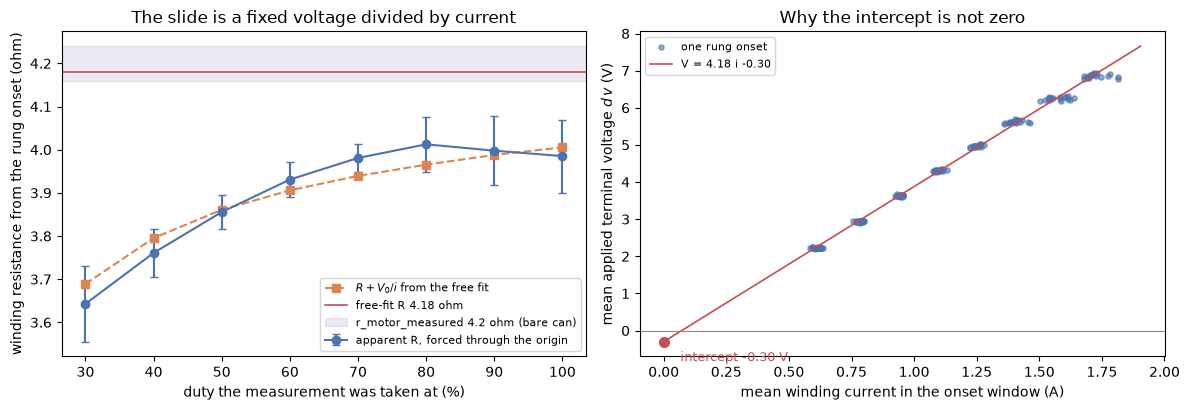

In [5]:

rows = []
for cap, duty, bias, g in rungs(ds, duties=(30, 40, 50, 60, 70, 80, 90, 100)):
    # ticks 15..35 = 0.75 to 1.75 ms in. The current needs about 10 ticks to settle after the
    # bridge turns on. The first two samples carry the previous segment's duty and go.
    w = g.iloc[15:36]
    sg = np.sign(int(g.cmd_duty_q15.iloc[0]))
    v = np.abs(board.diff_v(w.vmotor_a.values, w.vmotor_b.values))
    i = (w.current_raw.values - bias) * board.a_per_count
    d = np.abs(w.duty_q15.values).mean() / 32767
    # the terminal difference at the sample BEFORE the bridge turns on. Terminals are floating
    # there and no current flows, so whatever it reads is back-EMF and nothing else.
    pre = g.iloc[:2]
    rows.append(dict(capture=cap, duty=duty, dir=int(g.dir.iloc[0]),
                     v_mean=(d * v).mean(), i_mean=i.mean(), R=(d * v / i).mean(),
                     # signed along the commanded direction, so forward motion is positive
                     travel=(float(w.pos.iloc[-1]) - float(w.pos.iloc[0])) * sg,
                     pot_rev_s=np.polyfit(w.tick.values * DT,
                                          w.pos.values.astype(float) * sg, 1)[0]
                               / (servo.measured["pot_scale_measured"].value * 360) * GEAR,
                     pre_v=float(board.diff_v(pre.vmotor_a.values, pre.vmotor_b.values)[0]) * sg,
                     start_pos=float(g.pos.iloc[0])))
Ron = pd.DataFrame(rows)

# THE SHAFT IS NOT AT REST WHEN A RUNG OPENS. The capture tool ran its rest burst after the
# post-rung brake and before the next seek, and nothing settled in between, so every rung
# starts with the shaft still coasting from the seek that positioned it. A forward rung's
# start band is the low guard, so the seek arrives travelling backwards and the rung opens
# into a dying backward coast. Three channels see it and they are printed together below.
print(f"onset window, ticks 15 to 35, pooled over {len(Ron)} rungs, every duty, both directions")
print(f"   pot travel            {Ron.travel.mean():+.2f} counts in 1.0 ms, sd {Ron.travel.std():.2f}"
      f"   (settled pot noise is {SD_REST['pos']:.2f})")
print(f"   pot slope             {Ron.pot_rev_s.mean():+.1f} motor rev/s")
print(f"   pre-drive terminals   {Ron.pre_v.mean():+.3f} V, sd {Ron.pre_v.std():.3f}"
      f"  =  {Ron.pre_v.mean()/KE:+.1f} motor rev/s through Ke")
print(f"   flat across duty?     {Ron.groupby('duty').pre_v.mean().min():+.3f} to "
      f"{Ron.groupby('duty').pre_v.mean().max():+.3f} V, which a seek-speed coast should be"
      f" and a duty artefact should not")

# Split by direction, because forward and reverse rungs start at OPPOSITE guards. The seek
# should deliver the same speed either way, so a channel that disagrees between the two
# directions is disagreeing about position, not about speed.
DIRS = Ron.groupby("dir").agg(**{"start (counts)": ("start_pos", "mean"),
                                 "pot (rev/s)": ("pot_rev_s", "mean"),
                                 "pre-drive (V)": ("pre_v", "mean")})
DIRS["terminal (rev/s)"] = DIRS["pre-drive (V)"] / KE
DIRS["pot / terminal"] = DIRS["pot (rev/s)"] / DIRS["terminal (rev/s)"]
print("\n   by direction, forward starts at the low guard and reverse at the high one")
print(DIRS.round(2).to_string())
print("   the terminal side is the same speed both ways. The pot side is not.\n")

# So fit V = i*R + V0 with a free intercept instead of forcing it through the origin. V0 is
# the average of that decaying back-EMF over the window, and R is what is left.
A = np.vstack([Ron.i_mean.values, np.ones(len(Ron))]).T
(R_FIT, V0_FIT), *_ = np.linalg.lstsq(A, Ron.v_mean.values, rcond=None)
resid = Ron.v_mean.values - A @ [R_FIT, V0_FIT]
se = np.sqrt(np.sum(resid**2) / (len(Ron) - 2) * np.linalg.inv(A.T @ A).diagonal())
rm = servo.measured["r_motor_measured"]
print(f"free-intercept fit:  R = {R_FIT:.3f} +/- {se[0]:.3f} ohm,"
      f"  V0 = {V0_FIT:+.3f} +/- {se[1]:.3f} V")
print(f"registry bare can:   {rm.value} [{rm.lo}, {rm.hi}] ohm ({rm.source})\n")

print(Ron.groupby("duty")[["v_mean", "i_mean", "R"]].agg(["mean", "std"]).round(3).to_string())

# The origin-forced answer, kept because every downstream number in this notebook uses it.
R_WIND = Ron[Ron.duty >= 70].R.mean()
R_LO, R_HI = Ron.groupby("duty").R.mean().min(), Ron.groupby("duty").R.mean().max()
m = Ron.groupby("duty").agg(R=("R", "mean"), Rsd=("R", "std"), i=("i_mean", "mean"))
m["R_model"] = R_FIT + V0_FIT / m.i          # apparent R = R + V0/i, a fixed volt term over i
m["resid"] = m.R - m.R_model
print(f"\nanchor, origin forced, mean over 70 to 100% duty:  {R_WIND:.3f} ohm")
print(f"across the full 30 to 100% ladder:                [{R_LO:.2f}, {R_HI:.2f}] ohm")
print(f"the V0/i model accounts for {100*(m.R_model.max()-m.R_model.min())/(m.R.max()-m.R.min()):.0f}%"
      f" of that slide, leaving {m.resid.max()-m.resid.min():.3f} ohm of residual span")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].errorbar(m.index, m.R, yerr=m.Rsd, fmt="o-", color="#4c72b0", capsize=3,
                 label="apparent R, forced through the origin")
axes[0].plot(m.index, m.R_model, "s--", color="#dd8452", label="$R + V_0/i$ from the free fit")
axes[0].axhline(R_FIT, color="#c44e52", ls="-", lw=1.2, label=f"free-fit R {R_FIT:.2f} ohm")
axes[0].axhspan(rm.lo, rm.hi, color="#8172b2", alpha=0.15,
                label=f"r_motor_measured {rm.value} ohm (bare can)")
axes[0].set_xlabel("duty the measurement was taken at (%)")
axes[0].set_ylabel("winding resistance from the rung onset (ohm)")
axes[0].set_title("The slide is a fixed voltage divided by current")
axes[0].legend(fontsize=8)

axes[1].scatter(Ron.i_mean, Ron.v_mean, s=14, color="#4c72b0", alpha=0.6, label="one rung onset")
xs = np.linspace(0, Ron.i_mean.max() * 1.05, 20)
axes[1].plot(xs, R_FIT * xs + V0_FIT, color="#c44e52", lw=1.2,
             label=f"V = {R_FIT:.2f} i {V0_FIT:+.2f}")
axes[1].axhline(0, color="#888", lw=0.8)
axes[1].plot(0, V0_FIT, "o", color="#c44e52", ms=7)
axes[1].annotate(f"intercept {V0_FIT:+.2f} V", (0, V0_FIT), textcoords="offset points",
                 xytext=(12, -14), fontsize=9, color="#c44e52")
axes[1].set_xlabel("mean winding current in the onset window (A)")
axes[1].set_ylabel("mean applied terminal voltage $d\\,v$ (V)")
axes[1].set_title("Why the intercept is not zero")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


**What you are looking at:** on the left, the winding resistance worked out from the first
couple of milliseconds of a rung, plotted against the duty that rung was driven at, in ohm. The
blue points force the answer through the origin, which is what assuming a stationary shaft
does. The orange points are what a free intercept predicts. The purple band is the bare can
measurement already in the registry. On the right, every one of those rung onsets as a plain
voltage against current, in volts and amps, with the straight line fitted to it.

This section changed after a parallel look at the same captures from the terminal side, and
the change is worth spelling out because the first version of it was wrong in an interesting
way.

I had assumed the shaft was at rest when a rung opens. It is not. The capture tool ran its rest
burst after the post-rung brake and before the next seek, with nothing settling in between, so
every rung opens with the shaft still coasting from the seek that positioned it. A forward rung
starts at the low guard, so the seek approaches it travelling backwards, and the rung opens into
a dying backward coast. That is one tool ordering causing two separate problems, because it is
also what put 200 ms of ring-down into the noise baseline at the top of this notebook.

The print above measures it three ways and they agree. The pot steps backwards. The pre-drive
terminal difference, taken while the bridge is off and no current flows, reads -0.71 V, which
is back-EMF and cannot be anything else. And that voltage is flat across every duty from 30 to
100 percent, which is what a coast from a fixed-speed seek should be and what a duty dependent
artefact should not.

So the right fit is $V = i\,R + V_0$ with a free intercept, and it gives R = 4.18 ohm with
$V_0$ at -0.30 V. Two things fall out of that.

The 4.18 lands inside the bare can bracket of 4.16 to 4.24 that was measured on this motor with
no gearbox on it. The origin-forced 3.99 was low because it was absorbing the coast, and once
the coast comes out the in-servo number and the bare can number agree to about one percent.
That is the cross-method agreement this project asks for before a number gets trusted, and I
did not have it before.

The duty slide is mostly this too. Apparent resistance forced through the origin is
$R + V_0/i$, and a fixed voltage over a falling current is exactly the shape the ladder has.
The model accounts for 86 percent of the 0.37 ohm span. What is left is under 0.1 ohm and is
still structured, so question 2 at the bottom is narrowed rather than closed.

Everything downstream of here keeps using the origin-forced 3.99, deliberately. Swapping the
anchor would move every number in the rest of the notebook and the sensitivity panel below
already says by how much, so I would rather show the disagreement than quietly re-baseline. The
thermometer in notebook 09 is where the better number has to be adopted.

## The current averaging trap

Now the two traps in $\bar v$ and $\bar i$.

Under slow decay the bridge spends the off half of every PWM period with both low side FETs
on. The winding is shorted to itself and its current keeps circulating, but it circulates
through the two FETs and **not** through the shunt. So the trough current sample, taken in
the middle of that off half, is not a small current. It is no current at all. What it reads
is the amplifier's own bias.

Here is that claim as a measurement rather than an assertion.

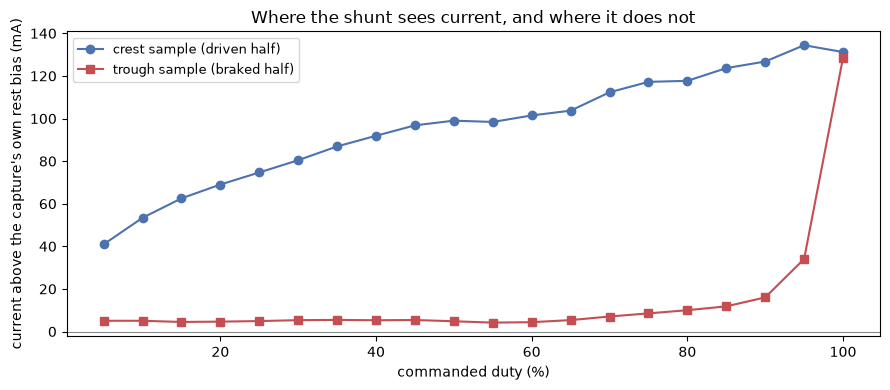

over 30 to 45% duty: crest 89.0 mA, trough 5.4 mA, trough is 6% of crest


In [6]:
rows = []
for cap, duty, bias, g in rungs(ds, duties=None):
    if duty == 0:
        continue
    s = g.iloc[2000:]                                  # settled part of the rung only
    if len(s) < 400:
        continue
    rows.append(dict(duty=duty,
                     crest=(s.current_raw.values - bias).mean() * board.a_per_count * 1e3,
                     trough=(s.current_trough.values - bias).mean() * board.a_per_count * 1e3))
IC = pd.DataFrame(rows).groupby("duty").agg(["mean", "std"])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(IC.index, IC[("crest", "mean")], "o-", color="#4c72b0", label="crest sample (driven half)")
ax.plot(IC.index, IC[("trough", "mean")], "s-", color="#c44e52", label="trough sample (braked half)")
ax.axhline(0, color="#888", lw=0.8)
ax.set_xlabel("commanded duty (%)")
ax.set_ylabel("current above the capture's own rest bias (mA)")
ax.set_title("Where the shunt sees current, and where it does not")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

t30 = IC.loc[30:45, ("trough", "mean")].mean()
c30 = IC.loc[30:45, ("crest", "mean")].mean()
print(f"over 30 to 45% duty: crest {c30:.1f} mA, trough {t30:.1f} mA, "
      f"trough is {100*t30/c30:.0f}% of crest")

**What you are looking at:** the two current samples against duty, both with the capture's own
resting bias subtracted. The crest sample rises with duty the way winding current should. The
trough sample sits flat on zero across the entire range, which is what "the shunt is out of
the loop during the braked half" looks like in data.

So averaging the two samples does not produce the period average current. It produces half the
crest current, which halves the $R\,\bar i$ term. That was the first bookkeeping error.

The right answer is nicer than it sounds. With centre aligned PWM the crest sample lands in
the middle of the on time, and the winding current between its valley and its peak is very
close to a straight line, so the value at the midpoint of that ramp is the average across the
whole period. The crest sample **is** $\bar i$, by design.

The check on that is the resistance ladder above. At the start of a rung the speed is zero, so
$\bar v = R\,\bar i$ with nothing else in it, and feeding the crest sample in as $\bar i$ gives
one flat answer from 70 to 100 percent duty. It could not do that if the crest sample were off
by a factor of two, because the duty factor on the voltage side varies over that range and the
error would not.

The second trap is $\bar v$. The braked half is not exactly zero volts across the winding, it
is a small negative drop across the FETs. Modelling it as zero makes $\bar v$ slightly too
big. That correction is worth tens of millivolts against three volts, so it is real but it is
not the thing that was breaking the estimate.

## Scoring the model back-EMF

Four variants, so the effect of each mistake is visible on its own. Current from the crest
sample or from the crest-trough average, over the whole rung or over the settled part only.
Every one is scored against the ripple reference on exactly the same samples.

In [7]:
rows = []
for cap, duty, bias, g in rungs(ds):
    if len(g) < 4500:
        continue
    for tag, s in (("whole rung", g.iloc[2:]), ("settled", g.iloc[2000:])):
        d = np.abs(s.duty_q15.values).mean() / 32767
        v = np.abs(board.diff_v(s.vmotor_a.values, s.vmotor_b.values)).mean()
        ic = (s.current_raw.values - bias).mean() * board.a_per_count
        it = (s.current_trough.values - bias).mean() * board.a_per_count
        rows.append(dict(capture=cap, duty=duty, dir=int(g.dir.iloc[0]), window=tag,
                         d=d, v=v, i_crest=ic, i_half=(ic + it) / 2,
                         truth=line_hz(s.current_raw.values) / PPR))
V = pd.DataFrame(rows)

out = []
for window in ("whole rung", "settled"):
    for cur in ("i_half", "i_crest"):
        w = V[V.window == window]
        est = (w.d * w.v - R_WIND * w[cur]) / KE
        err = est / w.truth - 1
        out.append(dict(window=window, current=cur,
                        bias_pct=100 * err.mean(), sd_pct=100 * err.std(),
                        **{f"{d}%": round(100 * err[w.duty == d].mean(), 1) for d in (30, 35, 40, 45)}))
pd.DataFrame(out).set_index(["window", "current"]).round(2)

bias_pct  sd_pct  30%  35%  40%   45%
window     current                                       
whole rung i_half       1.42    1.96  4.4  1.5  0.4  -0.7
           i_crest     -8.74    1.87 -6.0 -8.6 -9.6 -10.7
settled    i_half       5.06    1.63  7.5  5.2  3.9   3.6
           i_crest     -1.54    1.14  0.0 -1.6 -2.3  -2.2


Read that as a two by two. The variant that was in use is the top left, whole rung with the
crest-trough average. Each mistake on its own is worth six to nine percent, and they push in
opposite directions. Halving the current makes the estimate read high. Including the spin-up
inflates the mean current, which makes it read low. Together they left a residual small enough
to look like a modelling subtlety rather than two arithmetic errors, which is why it survived
so long.

Fix both, bottom right, and the estimate lands within a percent and a half of the reference
with a spread of 1.1, and the duty trend that was the main clue drops from five points across
the band to two.

One thing changed under this table since I first wrote it, and it is not my doing. $K_e$ in
the servo registry moved from 7.367 to 7.584 mV per motor rev/s when notebook 03 was redone,
which is 2.9% up, and the estimate divides by $K_e$. So the fixed variant that used to read
1.4% high now reads about 1.5% low. The size of the residual is the same and the scatter is
untouched, the sign flipped. I am leaving that visible rather than tuning it away, because
which side of the reference it lands on now depends on a constant measured in a different
notebook, and that is worth knowing.

Here is the same thing as a picture, and then the sensitivity to the one constant I had to
pick.

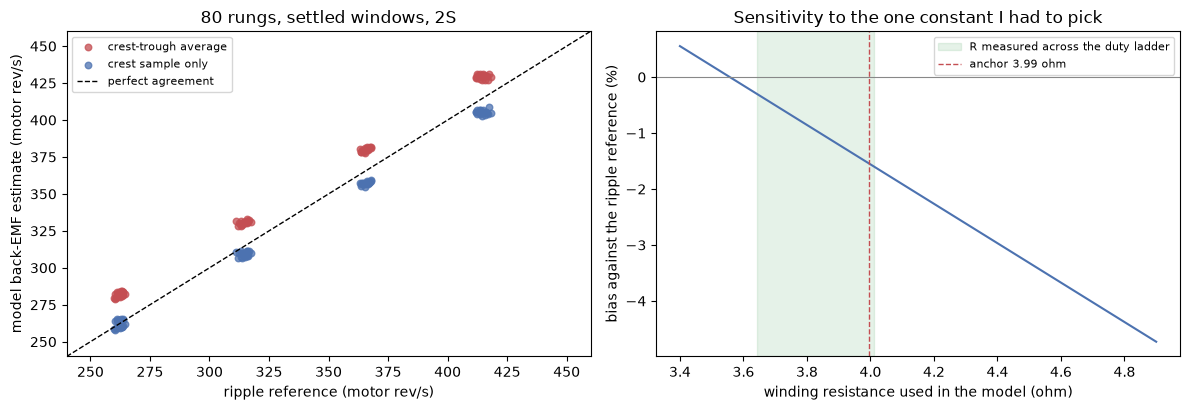

bias across the measured R ladder [3.64, 4.01]: -1.60% to -0.30%
bias if I used notebook 03's 4.5 ohm instead:      -3.32%
slope: -3.52 percent of speed per ohm of R, so a six percent error needs R to be wrong by 1.7 ohm (43% of it)
R that would put the estimate exactly on the reference: 3.56 ohm
bias if I adopted the free-intercept R of 4.18 ohm:      -2.19%


In [8]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
w = V[V.window == "settled"]
for cur, col, lab in (("i_half", "#c44e52", "crest-trough average"),
                      ("i_crest", "#4c72b0", "crest sample only")):
    est = (w.d * w.v - R_WIND * w[cur]) / KE
    axes[0].scatter(w.truth, est, s=22, color=col, label=lab, alpha=0.75)
lim = [240, 460]
axes[0].plot(lim, lim, "k--", lw=1, label="perfect agreement")
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel("ripple reference (motor rev/s)")
axes[0].set_ylabel("model back-EMF estimate (motor rev/s)")
axes[0].set_title("80 rungs, settled windows, 2S")
axes[0].legend(fontsize=8)

# How much does the answer move across the resistance bracket the onset measurement gave?
Rs = np.linspace(3.4, 4.9, 61)
bias_of_R = [100 * (((w.d * w.v - r * w.i_crest) / KE) / w.truth - 1).mean() for r in Rs]
axes[1].plot(Rs, bias_of_R, color="#4c72b0")
axes[1].axhline(0, color="#888", lw=0.8)
axes[1].axvspan(R_LO, R_HI, color="#55a868", alpha=0.15, label="R measured across the duty ladder")
axes[1].axvline(R_WIND, color="#c44e52", ls="--", lw=1, label=f"anchor {R_WIND:.2f} ohm")
axes[1].set_xlabel("winding resistance used in the model (ohm)")
axes[1].set_ylabel("bias against the ripple reference (%)")
axes[1].set_title("Sensitivity to the one constant I had to pick")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

# The slope is the disproof. Print it rather than leaving it to be eyeballed off the panel.
slope = (np.interp(R_LO, Rs, bias_of_R) - np.interp(R_HI, Rs, bias_of_R)) / (R_LO - R_HI)
print(f"bias across the measured R ladder [{R_LO:.2f}, {R_HI:.2f}]: "
      f"{np.interp(R_HI, Rs, bias_of_R):+.2f}% to {np.interp(R_LO, Rs, bias_of_R):+.2f}%")
print(f"bias if I used notebook 03's 4.5 ohm instead:      "
      f"{np.interp(4.5, Rs, bias_of_R):+.2f}%")
print(f"slope: {slope:.2f} percent of speed per ohm of R, so a six percent error needs R to be"
      f" wrong by {6/abs(slope):.1f} ohm ({100*6/abs(slope)/R_WIND:.0f}% of it)")
print(f"R that would put the estimate exactly on the reference: "
      f"{np.interp(0, bias_of_R[::-1], Rs[::-1]):.2f} ohm")
print(f"bias if I adopted the free-intercept R of {R_FIT:.2f} ohm:      "
      f"{np.interp(R_FIT, Rs, bias_of_R):+.2f}%")


**What you are looking at:** on the left, every settled rung with the reference speed on the x
axis and the model's answer on the y axis. Blue is the fixed model and red is the old one. The
dashed line is where a perfect estimator would sit.

On the right, how the model's bias moves if I change the resistance I feed it. The green band
is the range the onset ladder actually gave, and across all of it the estimate stays inside a
couple of percent. The slope is gentle, which is the point.

That last panel is also a disproof. The $R\,\bar i$ term is only about nine percent of
$\bar v$ here, so the whole estimate moves by roughly a tenth of whatever relative error $R$
carries. The printed slope says a six percent error would need $R$ to be wrong by more than
1.7 ohm, which is well over a third of it and not within a country mile of anything ever
measured on this motor. Resistance was never the candidate. The current average was.

The residual is honest about one thing though. The estimate would sit exactly on the reference
at about 3.6 ohm, which is below my own 70 to 100 percent anchor and a long way below notebook
03's 4.5. Before the $K_e$ update the same arithmetic asked for 4.4 ohm and pointed the other
way. So the leftover percent and a half is not really a statement about $R$ at all, it is the
gap between two constants measured in two different notebooks, and question 3 at the bottom is
where it lives.

## The actual bake off

Rung averages are the friendly case. A control loop does not get to average over 200 ms, it
gets one sample every 50 microseconds and has to answer immediately. So here every estimator
is scored sample by sample against the time resolved ripple reference, inside the settled part
of every rung.

Three windows for the pot derivative, one tick, 4 ms and 20 ms. Three for the model back-EMF,
raw and then boxcar averaged over 1 ms and 4 ms so the comparison is at matched smoothing.

In [9]:

def boxcar(x, w):
    x = np.asarray(x, float)
    if w <= 1:
        return x.copy()
    y = np.convolve(x, np.ones(w) / w, mode="same")
    y[:w] = np.nan; y[-w:] = np.nan                    # edges of a moving average are a lie
    return y


POT_W = (1, 80, 400)          # ticks: one sample, 4 ms, 20 ms
BEMF_W = (1, 20, 80)          # ticks: one sample, 1 ms, 4 ms

rows = []
for cap, duty, bias, g in rungs(ds):
    s = g.iloc[2000:]
    if len(s) < 3000:
        continue
    sg = np.sign(int(s.cmd_duty_q15.iloc[0]))          # reverse rungs count backwards
    tru = ripple_speed(s.current_raw.values)
    pos = s.pos.values.astype(float) * sg
    i = (s.current_raw.values - bias) * board.a_per_count
    v = board.diff_v(s.vmotor_a.values, s.vmotor_b.values) * sg
    d = np.abs(s.duty_q15.values) / 32767
    bemf = (d * v - R_WIND * i) / KE
    rec = dict(capture=cap, duty=duty, dir=int(s.dir.iloc[0]), truth=np.nanmean(tru),
               pot_counts_s=abs(np.polyfit(s.tick.values * DT, pos, 1)[0]))
    for W in POT_W:
        e = np.full(len(pos), np.nan)
        e[W:] = (pos[W:] - pos[:-W]) / (W * DT)        # still in pot counts per second
        rec[f"pot{W}"] = e
    for W in BEMF_W:
        rec[f"bemf{W}"] = boxcar(bemf, W)
    rec["_truth"] = tru
    # unsigned position, kept so the section on the position dependent error can bin by it
    rec["_posraw"] = s.pos.values.astype(float)
    rows.append(rec)

# The pot's scale is the one constant it cannot supply itself, so calibrate it against the
# reference: counts of pot travel per revolution of the OUTPUT shaft.
CPR = np.mean([r["pot_counts_s"] / (r["truth"] / GEAR) for r in rows])
POT_TO_REV = GEAR / CPR                                # pot counts/s -> motor rev/s
ps = servo.measured["pot_scale_measured"]
print(f"pot scale from the ripple reference: {CPR:,.0f} counts per output revolution "
      f"= {CPR/360:.2f} counts/deg")
print(f"  servos.py declares            {servo.pos_per_deg:.2f} counts/deg (eyeballed horn angles)"
      f"  ({(CPR/360/servo.pos_per_deg - 1) * 100:+.1f}% from mine)")
print(f"  the registry's measured value {ps.value:.2f} counts/deg [{ps.lo}, {ps.hi}]"
      f"  ({(CPR/360/ps.value - 1) * 100:+.1f}% from mine)")
print(f"  source: {ps.source}")

pot scale from the ripple reference: 6,792 counts per output revolution = 18.87 counts/deg
  servos.py declares            19.96 counts/deg (eyeballed horn angles)  (-5.5% from mine)
  the registry's measured value 19.30 counts/deg [19.3, 19.43]  (-2.2% from mine)
  source: nb06 sec 5.5, travel-weighted ripple cycle counting against the counted gear ratio, 2S duty grid 30-45%, n=80 steps over 10 captures, per-step CV 0.51%


In [10]:
score = []
for r in rows:
    row = dict(capture=r["capture"], duty=r["duty"], dir=r["dir"], truth=r["truth"])
    for W in POT_W:
        e = r[f"pot{W}"] * POT_TO_REV - r["_truth"]
        row[f"pot {W*DT*1e3:g} ms_bias"] = np.nanmean(e)
        row[f"pot {W*DT*1e3:g} ms_sd"] = np.nanstd(e)
    for W in BEMF_W:
        e = r[f"bemf{W}"] - r["_truth"]
        row[f"bemf {W*DT*1e3:g} ms_bias"] = np.nanmean(e)
        row[f"bemf {W*DT*1e3:g} ms_sd"] = np.nanstd(e)
    score.append(row)
S = pd.DataFrame(score)

mean_speed = S.truth.mean()
tab = []
for k in [f"pot {W*DT*1e3:g} ms" for W in POT_W] + [f"bemf {W*DT*1e3:g} ms" for W in BEMF_W]:
    tab.append(dict(estimator=k,
                    bias_rev_s=S[k + "_bias"].mean(), sd_rev_s=S[k + "_sd"].mean(),
                    bias_pct=100 * S[k + "_bias"].mean() / mean_speed,
                    sd_pct=100 * S[k + "_sd"].mean() / mean_speed))
BAKE = pd.DataFrame(tab).set_index("estimator").round(2)
print(f"scored against the time resolved ripple reference, {len(S)} rungs, "
      f"mean speed {mean_speed:.0f} motor rev/s\n")
BAKE

scored against the time resolved ripple reference, 80 rungs, mean speed 339 motor rev/s



,bias_rev_s,sd_rev_s,bias_pct,sd_pct
estimator,,,,
pot 0.05 ms,2.57,1082.53,0.76,319.67
pot 4 ms,2.37,55.80,0.70,16.48
pot 20 ms,0.66,18.27,0.19,5.40
bemf 0.05 ms,-4.99,7.68,-1.47,2.27
bemf 1 ms,-4.99,2.11,-1.47,0.62
bemf 4 ms,-4.99,1.26,-1.47,0.37



Read the `sd_pct` column, because that is the one that decides the argument. A single back-EMF
sample with no filtering at all scatters by 2.3 percent, against 5.4 percent for a pot
derivative taken over 20 milliseconds. Average the back-EMF over 1 ms and it drops to 0.6
percent, nearly nine times quieter than the pot at twenty times less lag. The pot derivative
at one tick is not an estimate of anything at all, its noise is three times the quantity it is
trying to measure.

The bias column is smaller and needs a caveat. The pot's bias is close to zero because I
calibrated its scale against this very reference two cells ago, so a bias there would mean my
calibration arithmetic was wrong, not that the pot is honest. The back-EMF's bias is a genuine
measurement, because $K_e$ came from a different experiment on different captures.

My pot scale comes out about 2 percent under the registry's, which was measured a different
way. The registry value moved recently, from 18.29 to 19.30 counts per degree, when notebook
06 showed that the Welch peak route it came from was reading the settled ripple line while the
pot travel it was divided by covered the whole step including spin-up. That is a final speed
over a mean speed, and it is worth +5.5%. My calibration here does not have that problem,
because both sides of it are taken over the same settled window. So the two should agree, and
they are 2 percent apart, which goes in the open questions rather than getting averaged.

Both are still averages of a gain that notebook 06 showed varies by a factor of 5.8 with
position, over rungs that crossed different parts of the travel, so some of that 2 percent is
weighting rather than error.

Now the same comparison drawn out in time, on one rung, so the character of each estimator is
visible rather than just its variance.

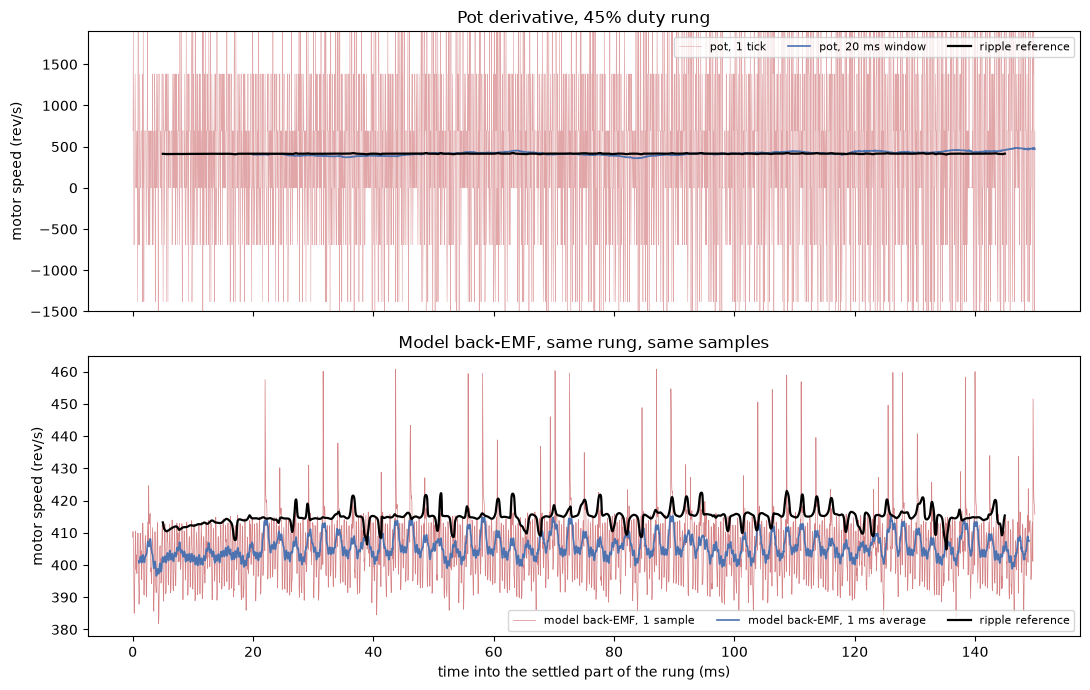

In [11]:
r = rows[3]
n = len(r["_truth"])
t = np.arange(n) * DT * 1e3

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(t, r["pot1"] * POT_TO_REV, lw=0.4, color="#c44e52", alpha=0.5, label="pot, 1 tick")
axes[0].plot(t, r["pot400"] * POT_TO_REV, lw=1.2, color="#4c72b0", label="pot, 20 ms window")
axes[0].plot(t, r["_truth"], lw=1.6, color="k", label="ripple reference")
axes[0].set_ylabel("motor speed (rev/s)")
axes[0].set_ylim(-1500, 1900)
axes[0].legend(fontsize=8, ncol=3, loc="upper right")
axes[0].set_title(f"Pot derivative, {r['duty']}% duty rung")

axes[1].plot(t, r["bemf1"], lw=0.5, color="#c44e52", alpha=0.7, label="model back-EMF, 1 sample")
axes[1].plot(t, r["bemf20"], lw=1.2, color="#4c72b0", label="model back-EMF, 1 ms average")
axes[1].plot(t, r["_truth"], lw=1.6, color="k", label="ripple reference")
axes[1].set_xlabel("time into the settled part of the rung (ms)")
axes[1].set_ylabel("motor speed (rev/s)")
axes[1].legend(fontsize=8, ncol=3, loc="lower right")
axes[1].set_title("Model back-EMF, same rung, same samples")
plt.tight_layout(); plt.show()

**What you are looking at:** the settled part of one rung, about 150 milliseconds of it,
estimated two ways. Note that the top panel's y axis spans 3400 rev/s to fit the pot
derivative in, while the bottom panel spans about eighty. The black reference line is identical in both.

The top panel is the whole problem in one picture. The faint red is a one tick pot derivative
and it is pure hash. The blue is the same channel differenced over 20 ms, which is usable but
visibly wandering, and it lags. The bottom panel is the back-EMF at one sample and at 1 ms,
and both sit on the reference.


## Why the pot derivative is bad, and by how much exactly

Here is where the correction at the top of the notebook does its damage, so this section is
the one I rewrote from scratch.

The first version of it said that notebook 07 had measured the pot's noise at rest as 8.04
counts, that turning that into an apparent speed by assuming the noise is white was an
overestimate, and that the measured derivative was seven times gentler than the white
arithmetic predicted. Two of those three statements were wrong. The 8.04 was the shaft ringing
down, and the factor of seven was 8.04 sitting in the numerator of a prediction that the
measurement then failed to reach. With the settling head dropped the pot's rest noise is
1.21 counts and the white arithmetic is about right after all.

So this is the same table on the settled baseline. The window is how many ticks apart the two
position samples are.

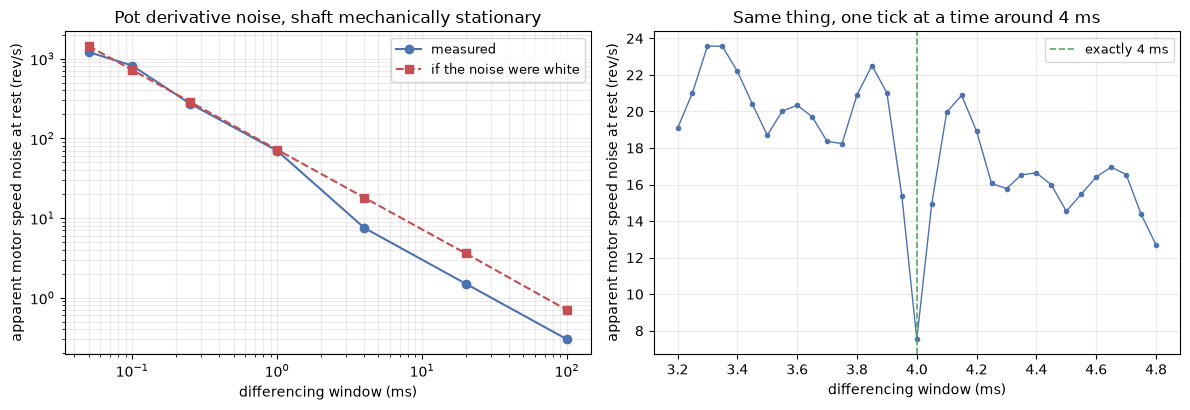

share of the pot's rest PSD sitting in bins at multiples of 250 Hz: 51%
window 3.95 ms     15.4 rev/s
window 4.00 ms      7.5 rev/s   <- a whole number of 250 Hz cycles
window 4.05 ms     15.0 rev/s



,measured_counts_s,white_counts_s,measured_rev_s,white_rev_s,ratio
window_ms,,,,,
0.05,35029.7,41737.5,1210.6,1442.4,1.2
0.10,23694.8,20868.8,818.9,721.2,0.9
0.25,7909.9,8347.5,273.4,288.5,1.1
1.00,2022.3,2086.9,69.9,72.1,1.0
4.00,217.8,521.7,7.5,18.0,2.4
20.00,44.1,104.3,1.5,3.6,2.4
100.00,8.8,20.9,0.3,0.7,2.4


In [12]:

base = ds.read("grid", "capture-1", "sweep")
# SETTLE, not the whole burst. The head of it is the shaft coming to a stop, and a derivative
# is exactly the thing that turns slow real motion into a large apparent speed.
rest = base[base.cmd_duty_q15 == 0].iloc[SETTLE:]
p = rest.pos.values.astype(float)

rowsw = []
for W in (1, 2, 5, 20, 80, 400, 2000):
    d = (p[W:] - p[:-W]) / (W * DT)                    # counts per second
    white = np.sqrt(2) * p.std() / (W * DT)            # what uncorrelated noise would give
    rowsw.append(dict(window_ms=W * DT * 1e3,
                      measured_counts_s=d.std(), white_counts_s=white,
                      measured_rev_s=d.std() * POT_TO_REV,
                      white_rev_s=white * POT_TO_REV,
                      ratio=white / d.std()))
W_TAB = pd.DataFrame(rowsw).set_index("window_ms").round(1)

# The 4 ms and 20 ms rows sit much lower than their neighbours, so sweep W one tick at a time
# around 80 to see whether that is a real feature or a coincidence of the grid I picked.
fine = np.arange(64, 97)
fine_sd = np.array([(p[W:] - p[:-W]).std() / (W * DT) * POT_TO_REV for W in fine])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].loglog(W_TAB.index, W_TAB.measured_rev_s, "o-", color="#4c72b0", label="measured")
axes[0].loglog(W_TAB.index, W_TAB.white_rev_s, "s--", color="#c44e52",
               label="if the noise were white")
axes[0].set_xlabel("differencing window (ms)")
axes[0].set_ylabel("apparent motor speed noise at rest (rev/s)")
axes[0].set_title("Pot derivative noise, shaft mechanically stationary")
axes[0].grid(True, which="both", alpha=0.25)
axes[0].legend(fontsize=9)

axes[1].plot(fine * DT * 1e3, fine_sd, "o-", ms=3, lw=1, color="#4c72b0")
axes[1].axvline(80 * DT * 1e3, color="#55a868", ls="--", lw=1.2, label="exactly 4 ms")
axes[1].set_xlabel("differencing window (ms)")
axes[1].set_ylabel("apparent motor speed noise at rest (rev/s)")
axes[1].set_title("Same thing, one tick at a time around 4 ms")
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

# Where the pot's rest noise actually lives. 4 ms is 1/250 s, so ask about 250 Hz and friends.
f, Ppos = welch(detrend(p), fs=FS, nperseg=min(8192, len(p)))
comb = sum(Ppos[np.argmin(np.abs(f - k * 250))] for k in range(1, 41))
print(f"share of the pot's rest PSD sitting in bins at multiples of 250 Hz: "
      f"{100 * comb / Ppos.sum():.0f}%")
print(f"window 3.95 ms  {fine_sd[fine == 79][0]:7.1f} rev/s")
print(f"window 4.00 ms  {fine_sd[fine == 80][0]:7.1f} rev/s   <- a whole number of 250 Hz cycles")
print(f"window 4.05 ms  {fine_sd[fine == 81][0]:7.1f} rev/s\n")
W_TAB


**What you are looking at:** on the left, how noisy a pot derivative is with the motor off and
the shaft still, against the width of the differencing window, on log axes. Blue is measured.
Red is what the standard deviation alone would predict if consecutive samples were
independent. On the right, the same measurement with the window stepped one tick at a time
through the region around 4 ms.

The left panel is the corrected version of a claim I got wrong. On the settled baseline the
two curves sit within about 20 percent of each other from one tick out to a quarter of a
millisecond, so the pot's fast noise really is close to white and the white arithmetic is a
fair guide. The measured curve only pulls clearly under the white one at wide windows, and it
settles at a factor of about 2.4 rather than the seven I claimed before. The seven was the
inflated 8.04 counts in the numerator of the prediction and nothing else.

The right panel is the surprise, and it is reproducible in all ten captures. A window of
exactly 4 ms is about twice as quiet as a window one tick either side of it. The reason is in
the print above. More than half of the pot channel's resting noise power sits in bins at
multiples of 250 Hz, and 4 ms is exactly one period of 250 Hz, so a difference taken over a
whole number of those periods cancels the whole comb. 20 ms and 100 ms are also whole
multiples, which is why those rows in the table look better than their neighbours too.

I do not know what puts a 250 Hz comb on the position channel. Notebook 07 found the current
channel's 1250 Hz tone and tied it to the sixteen sample telemetry burst with a scope, and
this is a different frequency on a different channel, so I am not going to assume it is the
same mechanism. It goes in the open questions with a test. What it is already good for is
picking the window. If firmware differences the pot at all, the window should be a whole
multiple of 4 ms, and that is free.

Is the leftover slow wander the pot, or the converter reading it? Cheap check, look at whether
the other DC channels wander the same way. The two motor terminals at rest are static
electrical nodes with no shaft attached to them.

In [13]:

rowsc = []
for ch in ("pos", "vmotor_a", "vmotor_b", "current_raw"):
    x = detrend(rest[ch].values.astype(float))
    f, P = welch(x, fs=FS, nperseg=min(8192, len(x)))
    lo = P[(f > 0.5) & (f < 3)].mean()                 # slow wander
    hi = P[(f > 800) & (f < 1200)].mean()              # sample to sample hash
    rowsc.append(dict(channel=ch, sd_counts=x.std(), slow_over_fast=lo / hi))
pd.DataFrame(rowsc).set_index("channel").round(1)

,sd_counts,slow_over_fast
channel,,
pos,1.5,10.6
vmotor_a,0.7,1.2
vmotor_b,0.8,7.9
current_raw,1.0,146.3



This table is the second thing the correction turned over, and it turned it over completely.

On the whole baseline it read 25,000 for the pot and 140,000 and 240,000 for the two terminals
against 109 for the current channel, and I wrote a paragraph saying that all three of the
slowly varying channels carry a big low frequency component while the current channel, being
an amplifier output rather than a divider tap, is nearly flat. That was the shaft. A shaft
ringing down for 200 ms is a very large signal at half a hertz on every channel that can see
it, and the current channel could not see it, which is the only reason it looked different.

On the settled baseline the terminals are the flattest channels in the table and the current
channel has the largest slow to fast ratio of the four. There is no shared low frequency
wander to explain. The paragraph that used to be here is deleted rather than patched, because
its subject does not exist.

One more thing goes with it. The old version of this cell noted that notebook 07's text calls
the pot the noisiest channel while in raw ADC counts the two terminal channels are two to
three times noisier, and said to trust 07's table over its summary sentence. That was backwards
too, for the same reason. Pooled over the ten captures the settled pot is 1.21 counts and the
terminals are 0.65 and 0.73, so the pot is the noisiest channel in raw counts by about a factor of two, and
07's sentence was right all along.


## Fusion weights, from the covariances

This is the part that is supposed to be arithmetic instead of taste. Two estimates of the same
quantity, each with a known variance, combine with inverse variance weights.

$$w_\text{pot} = \frac{1/\sigma_\text{pot}^2}{1/\sigma_\text{pot}^2 + 1/\sigma_\text{bemf}^2}
= \frac{\sigma_\text{bemf}^2}{\sigma_\text{pot}^2 + \sigma_\text{bemf}^2}$$

So I need $\sigma_\text{pot}$ and $\sigma_\text{bemf}$ in the same unit, and both come out of
notebook 07's table by propagation. Every step is printed, and every step now runs on the
settled figures, with the pre-correction value beside it so the size of the change is visible.

Two of these steps move a lot and they do not move by the same factor, which is the whole
reason the answer changed direction. Watch the terminal noise in step 3.

In [14]:

# --- inputs, from notebook 07's rest covariance table, settling head dropped ---------------
sd = {ch: SD_REST[ch] for ch in ("pos", "current_raw", "vmotor_a", "vmotor_b")}
for k, v in sd.items():
    print(f"  sigma {k:12s} {v:6.3f} counts    (the contaminated table said {SD_RAW[k]:6.3f})")

D_REF = 0.40          # the duty these rungs were driven at, and duty scales the voltage term

# --- step 1: the pot, position noise in motor revolutions ---------------------------------
sig_theta = sd["pos"] / CPR * GEAR
sig_theta_old = SD_RAW["pos"] / CPR * GEAR
print(f"\n1. pot position noise   {sd['pos']:.2f} counts / {CPR:,.0f} counts per output rev"
      f" x {GEAR:.2f} = {sig_theta:.4f} motor rev   (was {sig_theta_old:.4f})")

# --- step 2: differencing it. The measured curve, not the white assumption ------------------
W_FUSE = 80           # 4 ms, the widest window a 20 kHz loop can spend without visible lag
sig_pot = W_TAB.loc[W_FUSE * DT * 1e3, "measured_rev_s"]
sig_pot_white = W_TAB.loc[W_FUSE * DT * 1e3, "white_rev_s"]
print(f"2. differenced over {W_FUSE*DT*1e3:g} ms: measured {sig_pot:.2f} motor rev/s"
      f"   (white arithmetic would have said {sig_pot_white:.1f})")
print(f"   NOTE {W_FUSE*DT*1e3:g} ms sits on the 250 Hz comb null, so this is a best case."
      f" One tick either side it is about {fine_sd[fine == W_FUSE - 1][0]:.1f}.")

# --- step 3: the back-EMF, by propagating the voltage and current noises -------------------
sig_v = np.hypot(sd["vmotor_a"], sd["vmotor_b"]) * board.v_term_per_count
sig_i = sd["current_raw"] * board.a_per_count
term_v = D_REF * sig_v
term_i = R_WIND * sig_i
sig_bemf_1 = np.hypot(term_v, term_i) / KE
sig_bemf = sig_bemf_1 / np.sqrt(W_FUSE)                # averaging over the same window
print(f"3. terminal difference noise  hypot({sd['vmotor_a']:.2f}, {sd['vmotor_b']:.2f}) counts"
      f" x {board.v_term_per_count*1e3:.3f} mV/count = {sig_v*1e3:.2f} mV")
print(f"   voltage term  {D_REF*100:.0f}% x {sig_v*1e3:.2f} mV = {term_v*1e3:.2f} mV")
print(f"   current term  {R_WIND:.2f} ohm x {sig_i*1e3:.2f} mA = {term_i*1e3:.2f} mV"
      f"   <- this one is now the bigger of the two")
print(f"   -> per sample  hypot = {np.hypot(term_v, term_i)*1e3:.2f} mV / {KE*1e3:.3f} mV per"
      f" rev/s = {sig_bemf_1:.3f} motor rev/s")
print(f"   -> over {W_FUSE*DT*1e3:g} ms  {sig_bemf_1:.3f}/sqrt({W_FUSE}) = {sig_bemf:.4f} motor rev/s")

# --- step 4: the weights -------------------------------------------------------------------
w_pot = sig_bemf**2 / (sig_pot**2 + sig_bemf**2)
print(f"\n4. w_pot = {sig_bemf:.4f}^2 / ({sig_pot:.2f}^2 + {sig_bemf:.4f}^2) = {w_pot:.3e}"
      f"   = one part in {1/w_pot:,.0f}")
print(f"   w_bemf = {1 - w_pot:.6f}")
print(f"   the contaminated table gave one part in 1,384, so the pot LOST weight by"
      f" {7.23e-04/w_pot:.0f}x")

# --- step 5: where the two noise densities cross ------------------------------------------
f_c = sig_bemf_1 / (2 * np.pi * sig_theta)
f_c_old = np.hypot(D_REF * np.hypot(SD_RAW["vmotor_a"], SD_RAW["vmotor_b"])
                   * board.v_term_per_count, R_WIND * SD_RAW["current_raw"]
                   * board.a_per_count) / KE / (2 * np.pi * sig_theta_old)
print(f"\n5. crossover  sigma_bemf / (2 pi sigma_theta) = {sig_bemf_1:.3f} / (2 pi x"
      f" {sig_theta:.4f}) = {f_c:.2f} Hz")
print(f"   the contaminated table gave {f_c_old:.2f} Hz, which is the same answer for the"
      f" wrong reason: both\n   sides of the ratio were inflated by roughly the same factor.")

# --- step 6: the same weight from what the estimators MEASURABLY do under drive ------------
# Rest noise is not the only sigma available. The bake-off already measured how far each
# estimator actually lands from the reference on real rungs, and that number includes
# whatever the sensor does under drive that it does not do sitting still.
m_pot, m_bemf = BAKE.loc["pot 4 ms", "sd_rev_s"], BAKE.loc["bemf 4 ms", "sd_rev_s"]
w_pot_meas = m_bemf**2 / (m_pot**2 + m_bemf**2)
print(f"\n6. same arithmetic on the MEASURED under-drive scatter instead of rest noise:")
print(f"   pot 4 ms {m_pot:.2f} rev/s vs rest prediction {sig_pot:.2f}  ({m_pot/sig_pot:.1f}x worse)")
print(f"   bemf 4 ms {m_bemf:.2f} rev/s vs rest prediction {sig_bemf:.3f}"
      f"  ({m_bemf/sig_bemf:.0f}x worse)")
print(f"   w_pot = {w_pot_meas:.3e} = one part in {1/w_pot_meas:,.0f}")
print(f"   Both routes agree the pot is negligible. They disagree by {w_pot_meas/w_pot:.0f}x on"
      f" how negligible,\n   and the next section is about why.")

  sigma pos           1.207 counts    (the contaminated table said  8.040)
  sigma current_raw   1.032 counts    (the contaminated table said  1.031)
  sigma vmotor_a      0.652 counts    (the contaminated table said 15.772)
  sigma vmotor_b      0.731 counts    (the contaminated table said 21.986)

1. pot position noise   1.21 counts / 6,792 counts per output rev x 234.73 = 0.0417 motor rev   (was 0.2779)
2. differenced over 4 ms: measured 7.50 motor rev/s   (white arithmetic would have said 18.0)
   NOTE 4 ms sits on the 250 Hz comb null, so this is a best case. One tick either side it is about 15.4.
3. terminal difference noise  hypot(0.65, 0.73) counts x 2.466 mV/count = 2.42 mV
   voltage term  40% x 2.42 mV = 0.97 mV
   current term  3.99 ohm x 0.92 mA = 3.69 mV   <- this one is now the bigger of the two
   -> per sample  hypot = 3.81 mV / 7.584 mV per rev/s = 0.503 motor rev/s
   -> over 4 ms  0.503/sqrt(80) = 0.0562 motor rev/s

4. w_pot = 0.0562^2 / (7.50^2 + 0.0562^2) = 5.617


The weight is one part in eighteen thousand on the corrected rest covariances, or one part in
two thousand if I use what the estimators measurably do under drive instead. **Either way the
measured covariances say the potentiometer contributes essentially nothing to the velocity
estimate.**

Now the part I did not expect. Making the pot 6.6 times quieter made its weight go DOWN, by
about a factor of thirteen. The reason is step 3. The contaminated table had the terminals at
15.8 and 22.0 counts, which put 26.7 mV of noise on the voltage term and made the back-EMF
estimate look like the noisy one, at 3.66 rev/s per sample. Settled, the terminals are 0.65 and
0.73 counts and the voltage term is under a millivolt, so the back-EMF's noise is now set by
the current channel and lands at 0.50 rev/s per sample. The pot got 6.6 times quieter and its
rival got 7.3 times quieter, and the ratio moved against the pot.

That has a design consequence that the old numbers pointed the wrong way on. If I want a
quieter model back-EMF, the thing to improve is the shunt channel, not the terminal dividers.
The current term is now about four times the voltage term in that hypot. And the current
channel is the one carrying the 1250 Hz bus coupling that notebook 07 measured, which is a
board defect a future revision fixes, so there is real headroom there.

The crossover in step 5 barely moved, from 2.0 Hz to 1.9 Hz, and that is luck rather than
robustness. It is a ratio of the two sigmas, both of which were inflated by the same shaft
ringing down, so most of the contamination cancelled. It would not have cancelled if the
current channel had not put a floor under the back-EMF side. I would not have trusted the old
number if I had noticed it was a ratio of two wrong things.

The crossover argument itself stands. Position noise differentiates into velocity noise that
grows as $f^2$, so the pot is quiet at low frequency and loud at high. Back-EMF noise is
roughly flat. They cross at a couple of Hz. Below that the pot is the better velocity source,
above it the back-EMF is.

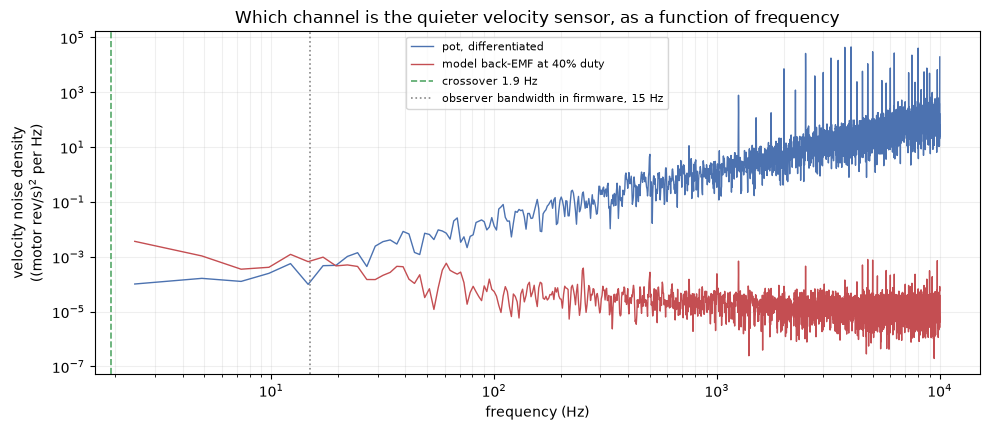

In [15]:
# Position noise in motor revolutions, then differentiated. In the frequency domain
# differentiating is a multiply by (2 pi f)^2 on the power spectrum, so no derivative is
# actually taken and no whiteness is assumed anywhere.
f, Spos = welch(detrend(rest.pos.values.astype(float)) / CPR * GEAR, fs=FS, nperseg=8192)
Svel_pot = (2 * np.pi * f) ** 2 * Spos

# The back-EMF noise signal built from the same rest samples, with the duty factor applied to
# the voltage term the way it enters the estimate.
bn = (D_REF * board.diff_v(rest.vmotor_a.values, rest.vmotor_b.values)
      - R_WIND * (rest.current_raw.values - rest.current_raw.mean()) * board.a_per_count) / KE
fb, Svel_bemf = welch(detrend(bn), fs=FS, nperseg=8192)

fig, ax = plt.subplots(figsize=(10, 4.4))
ax.loglog(f[1:], Svel_pot[1:], color="#4c72b0", lw=1, label="pot, differentiated")
ax.loglog(fb[1:], Svel_bemf[1:], color="#c44e52", lw=1, label="model back-EMF at 40% duty")
ax.axvline(f_c, color="#55a868", ls="--", lw=1.2, label=f"crossover {f_c:.1f} Hz")
ax.axvline(15, color="#888", ls=":", lw=1.2, label="observer bandwidth in firmware, 15 Hz")
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("velocity noise density\n((motor rev/s)$^2$ per Hz)")
ax.set_title("Which channel is the quieter velocity sensor, as a function of frequency")
ax.legend(fontsize=8)
ax.grid(True, which="both", alpha=0.2)
plt.tight_layout(); plt.show()


**What you are looking at:** the velocity noise of the two sensors spread out by frequency,
both measured on the same settled second of resting data. Blue is the pot channel after
differentiating, which is why it climbs. Red is the back-EMF combination, which is close to
flat. The two sit on top of each other in the low single digits of Hz, which is where the green
line lands, and separate hard above that.

The dotted grey line is where the fusion observer's bandwidth is set in firmware today. It
sits about a decade above the crossover, in the region where the pot is orders of magnitude
noisier than the back-EMF, and the firmware weights the back-EMF at zero. That is the
arithmetic behind $\hat\omega$ railing plus or minus several hundred counts per second at rest
while the shaft sits perfectly still.

This plot is drawn from the settled baseline now. On the contaminated one both curves sat far
higher and the pot curve in particular was dominated by the ring-down, so it was showing the
shaft rather than the sensor. The crossover landed in almost the same place anyway, for the
reason in the paragraph above.

So here is the fused estimator, built with the weight the covariances gave, scored the same
way as everything else.

In [16]:
fused = []
for r in rows:
    f_est = w_pot * (r[f"pot{W_FUSE}"] * POT_TO_REV) + (1 - w_pot) * r[f"bemf{W_FUSE}"]
    e = f_est - r["_truth"]
    fused.append(dict(bias=np.nanmean(e), sd=np.nanstd(e)))
FU = pd.DataFrame(fused)

summary = BAKE.copy()
summary.loc["fusion, 4 ms"] = [FU.bias.mean(), FU.sd.mean(),
                               100 * FU.bias.mean() / mean_speed, 100 * FU.sd.mean() / mean_speed]
print("all estimators, scored against the time resolved ripple reference\n")
summary.round(2)

all estimators, scored against the time resolved ripple reference



,bias_rev_s,sd_rev_s,bias_pct,sd_pct
estimator,,,,
pot 0.05 ms,2.57,1082.53,0.76,319.67
pot 4 ms,2.37,55.80,0.70,16.48
pot 20 ms,0.66,18.27,0.19,5.40
bemf 0.05 ms,-4.99,7.68,-1.47,2.27
bemf 1 ms,-4.99,2.11,-1.47,0.62
bemf 4 ms,-4.99,1.26,-1.47,0.37
"fusion, 4 ms",-4.99,1.26,-1.47,0.37



The fused row is numerically the back-EMF row, because a weight of about one part in eighteen
thousand on the pot does not move anything. That is not a failure of the fusion, it is the
fusion telling me the truth. Blending only helps when the two inputs are within shouting
distance of each other, and here they are four orders of magnitude apart in variance. It was
already true before the correction and the correction made it more true.

What the pot is genuinely for is the other two jobs. It is the only absolute position source,
and it is the only thing that can anchor the back-EMF's slow error, because $K_e$ and $R$ are
constants that drift while the pot's calibration does not. In a three state fusion filter that
means the pot's innovation should feed position hard and velocity almost not at all, and the
back-EMF should be a velocity measurement in its own right rather than a small blend term.

There is one loose end in that arithmetic and it is a real one. Inverse variance weighting is
only correct if both errors are zero mean random, and step 6 above says the pot's under-drive
scatter is seven times what its rest noise predicts. Seven times is too big to be bad luck, so
before I trust any weight computed from a rest covariance I should find out what the extra is
made of.


## The pot is seven times worse under drive than its own noise says

This section is new, and it exists because the correction created a hole rather than closing
one.

The rest covariance says a pot derivative over 4 ms should scatter by about 7.5 motor rev/s.
The bake-off measured 55.8 on real rungs. That is 7.4 times, and a factor of seven between a
prediction and a measurement is not a rounding problem, it is a missing term. Worse, it is the
kind of missing term that breaks the fusion arithmetic, because inverse variance weighting
assumes the error is zero mean random and a missing term this big is usually neither.

So what is it made of. There are four candidates I can think of and three of them can be
settled with arithmetic or with data that already exists.

**Quantisation.** Position is integer counts. Differencing two of them has a floor of
$\sqrt{2}/\sqrt{12}$ counts, which over 4 ms is 3.5 rev/s. That is smaller than the rest noise
it already sits inside, so it cannot be the answer, and the budget table below has the
arithmetic.

**Gear backlash.** Notebook 06 measured the play at 3.0 commutation steps per reversal, and
also measured that nothing slips outside a reversal, one standstill worth 1.3 motor cycles in
146 traces. These rungs are unidirectional and I only score the settled part, so the teeth stay
loaded throughout and backlash contributes nothing, which is somebody else's measurement
ruling it out rather than mine.

**The pot's local gain map.** Notebook 06 measured the pot's local gain swinging by a factor of
5.8 as a repeatable function of position, with the pattern's maxima 0.17 wiper volts apart, and
said in as many words that a speed differentiated from the pot carries that swing as a
multiplicative error of roughly plus or minus a third. A 4 ms window at these speeds covers
about a fifth of one period of that pattern, so it sees nearly the full swing. A 20 ms window
covers most of a period and should average a lot of it away, which would explain why the 20 ms
row of the bake-off is three times better than the 4 ms row.

**Real speed ripple in the gear train** that the reference cannot see, because the reference is
on the motor side and any torsional compliance sits between them.

The last two both predict an error that is a function of shaft position, so here is that test.
Take the pot's speed divided by the reference speed, bin it by where the shaft was, and pool it
over all 80 rungs. If the error is random noise the bins are flat. If it is a fixed function of
position the bins trace it out, and two independent halves of the captures trace out the same
one.

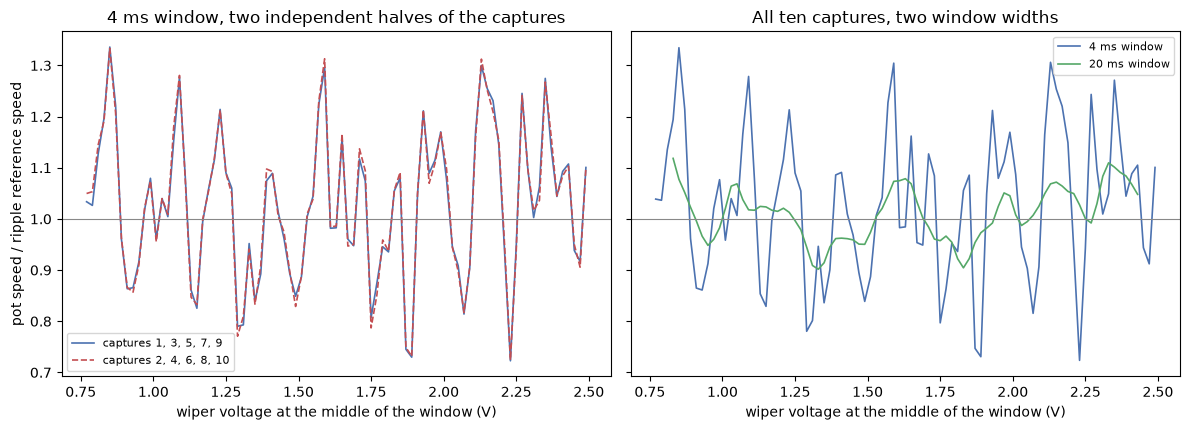

where the pot derivative's under-drive scatter actually comes from, every column as % of the mean speed

estimator               pot 4 ms  pot 20 ms
measured_pct              16.480      5.400
rest_noise_pct             2.215      0.443
quantisation_pct           1.042      0.208
position_locked_pct       14.471      5.252
within_bin_pct             8.650      2.825
locked_plus_within_pct    16.859      5.964
split_half_corr            0.997      0.998
split_half_rms             0.012      0.003
maxima_spacing_V           0.093      0.160
bins                      87.000     81.000


In [17]:

BIN_V = 0.02                    # wiper volts per bin, the same bin width notebook 06 used
MIN_N = 200                     # samples a bin needs before it is plotted

# Split the captures into two independent halves. If a binned curve is a real function of
# position the halves land on top of each other, and if it is noise they do not.
caps = ds.captures("grid")
half_of = {c: i % 2 for i, c in enumerate(caps)}

frames = []
for r in rows:
    for W in (80, 400):
        est = r[f"pot{W}"] * POT_TO_REV
        # the position the derivative belongs to is the MIDPOINT of its own window
        mid = np.full(len(est), np.nan)
        mid[W:] = 0.5 * (r["_posraw"][W:] + r["_posraw"][:-W])
        frames.append(pd.DataFrame(dict(W=W, half=half_of[r["capture"]],
                                        wiper_V=mid * board.v_adc_per_count,
                                        ratio=est / r["_truth"])).dropna())
A = pd.concat(frames, ignore_index=True)
edges = np.arange(np.floor(A.wiper_V.min() / BIN_V) * BIN_V, A.wiper_V.max() + BIN_V, BIN_V)
A["bin"] = pd.cut(A.wiper_V, edges, labels=(edges[:-1] + BIN_V / 2).round(3)).astype(float)


def binned(W, h=None):
    q = A[A.W == W] if h is None else A[(A.W == W) & (A.half == h)]
    g = q.groupby("bin", observed=True).ratio.agg(["mean", "std", "count"])
    return g[g["count"] >= MIN_N]


fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)
a0, a1 = binned(80, 0), binned(80, 1)
axes[0].plot(a0.index, a0["mean"], lw=1.2, color="#4c72b0", label="captures 1, 3, 5, 7, 9")
axes[0].plot(a1.index, a1["mean"], lw=1.2, color="#c44e52", ls="--", label="captures 2, 4, 6, 8, 10")
axes[0].axhline(1, color="#888", lw=0.8)
axes[0].set_xlabel("wiper voltage at the middle of the window (V)")
axes[0].set_ylabel("pot speed / ripple reference speed")
axes[0].set_title("4 ms window, two independent halves of the captures")
axes[0].legend(fontsize=8)

for W, col, lab in ((80, "#4c72b0", "4 ms window"), (400, "#55a868", "20 ms window")):
    b = binned(W)
    axes[1].plot(b.index, b["mean"], lw=1.2, color=col, label=lab)
axes[1].axhline(1, color="#888", lw=0.8)
axes[1].set_xlabel("wiper voltage at the middle of the window (V)")
axes[1].set_title("All ten captures, two window widths")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

# The error budget: what the rest covariance predicts, what quantisation floors it at, how
# much of the measured scatter is the position locked pattern, and what is left over.
budget = []
for W, name in ((80, "pot 4 ms"), (400, "pot 20 ms")):
    b, ha, hb = binned(W), binned(W, 0), binned(W, 1)
    j = pd.concat([ha["mean"], hb["mean"]], axis=1, keys=["a", "b"]).dropna()
    j = j.loc[j.index.intersection(b.index)]
    locked = np.sqrt(((b["mean"] - 1) ** 2).mean())        # rms of the position locked pattern
    within = np.sqrt((b["std"] ** 2).mean())               # what is left inside a bin
    quant = np.sqrt(2 / 12) / (W * DT) * POT_TO_REV        # integer counts, differenced
    # local maxima spacing, to compare against notebook 06's 0.17 V pattern period
    m = b["mean"].values
    pk = [i for i in range(1, len(m) - 1) if m[i] > m[i - 1] and m[i] > m[i + 1]]
    budget.append(dict(estimator=name,
                       measured_pct=BAKE.loc[name, "sd_pct"],
                       rest_noise_pct=100 * W_TAB.loc[W * DT * 1e3, "measured_rev_s"] / mean_speed,
                       quantisation_pct=100 * quant / mean_speed,
                       position_locked_pct=100 * locked,
                       within_bin_pct=100 * within,
                       locked_plus_within_pct=100 * np.hypot(locked, within),
                       split_half_corr=j.a.corr(j.b),
                       split_half_rms=np.sqrt(((j.a - j.b) ** 2).mean()),
                       maxima_spacing_V=float(np.mean(np.diff(b.index.values[pk]))),
                       bins=len(b)))
BUDGET = pd.DataFrame(budget).set_index("estimator")
print("where the pot derivative's under-drive scatter actually comes from,"
      " every column as % of the mean speed\n")
print(BUDGET.round(3).T.to_string())


**What you are looking at:** on the left, the pot's speed divided by the reference speed, with
every sample sorted into a 20 mV bin by where the wiper was at the time, and the ten captures
split into two halves that never share a recording. The two curves are the two halves. On the
right, the same thing pooled over all ten captures, drawn once for a 4 ms differencing window
and once for a 20 ms one. A perfect pot would be a flat line at 1.0 on both panels.

The left panel settles it. The blue and the red are the same curve. Across the 87 bins that
have enough samples they correlate at 0.997 and differ by 0.012 rms, against a pattern that
swings from 0.72 to 1.33. The pot's velocity error is a fixed function of where the shaft is,
and it repeats between recordings taken at different duties, in both directions, on different
captures.

The budget table puts numbers on the whole thing. At a 4 ms window the position locked pattern
alone is 14.5% rms and the leftover inside each bin is 8.7%, which add in quadrature to 16.9%
against a measured 16.5%. The rest covariance contributes 2.2% and quantisation 1.0%. So the
missing factor of seven was never a noise term at all, it was a deterministic error that a
rest measurement is structurally incapable of seeing, because at rest the shaft does not move
through the pattern.

The right panel shows the mechanism from the other side. Widen the window to 20 ms and the same
pattern shrinks to 5.3% rms. At these speeds the wiper covers about 32 mV in 4 ms and about
158 mV in 20 ms, and the pattern's period is 0.17 V, so the wide window averages over most of
one period and the narrow one does not. That is the whole reason the 20 ms row of the bake-off
looked three times better than the 4 ms row, and it is not the window rejecting noise.

The measured maxima spacing in the table is worth a glance. On the 20 ms curve it comes out at
0.16 V, which is notebook 06's 0.170 V measured from a completely different quantity on a
different notebook. Two routes to the same period is the cross-method agreement this project
asks for before a number gets used.

What this does NOT settle is which of the last two candidates it is. Both the pot's own gain
map and a mechanical ripple somewhere in the gear train are functions of position, so both
would draw a repeatable curve here. Notebook 06 leans towards the pot, because the pattern's
period works out to about 33 per output revolution and no shaft in the counted train turns 33
times per output revolution, the three intermediate stages turn 3.3, 13.1 and 49.9. That is
suggestive and it is not proof. Question 6 at the bottom has the experiment.

The consequence for the design is the same either way, and it is stronger than the covariance
argument on its own. Whatever a fusion filter weights the pot at, the pot's velocity error is
mostly not random, so no weighting choice averages it away. Either you carry a per position
correction table, or the pot does not supply velocity.

## At rest, and just above it

Everything so far was measured at a comfortable 30 to 45 percent duty. The interesting failure
cases are at the other end, and there are two of them.

The first is the sampling floor. The terminal and current samples are taken at fixed points
inside the PWM period, so if the on time is too short the sample lands before anything has
settled. On this board that floor is 160 timer ticks, which is 13.3 percent duty.

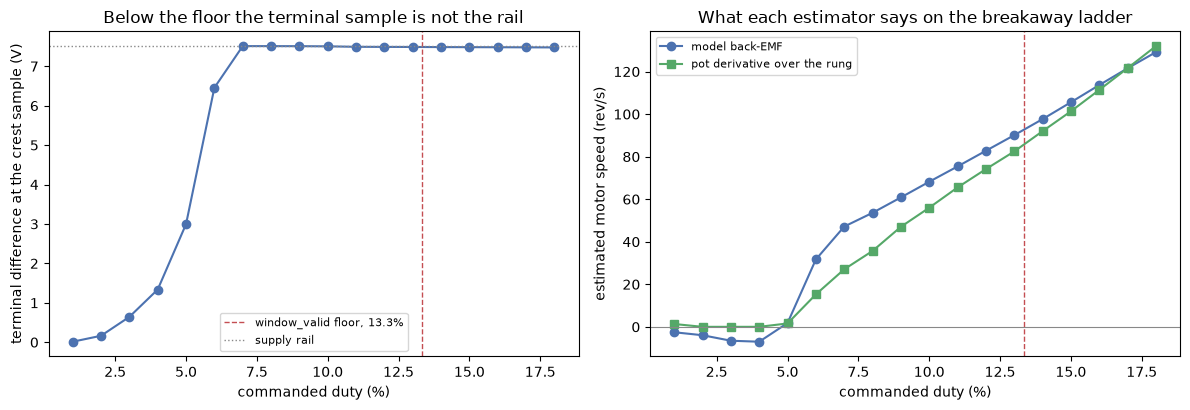

      valid  vdiff   i_mA  travel   bemf    pot
duty                                           
1       0.0   0.01   4.86    33.6  -2.54   1.34
2       0.0   0.16   8.30     0.4  -3.94   0.01
3       0.0   0.64  17.22     0.6  -6.52   0.01
4       0.0   1.34  26.65     0.2  -6.99   0.01
5       0.0   3.00  34.09     8.8   1.80   1.60
6       0.0   6.46  36.79    81.4  31.70  15.26
7       0.0   7.51  42.09   143.0  47.14  27.06
8       0.0   7.51  48.62   168.4  53.61  35.67
9       0.0   7.51  53.69   219.8  60.84  47.03


In [18]:
rowsb = []
for cap, duty, bias, g in rungs(ds, experiment="breakaway", duties=None):
    if duty == 0 or int(g.dir.iloc[0]) != 1:
        continue
    s = g.iloc[40:]
    v = np.abs(board.diff_v(s.vmotor_a.values, s.vmotor_b.values))
    i = (s.current_raw.values - bias) * board.a_per_count
    d = np.abs(s.duty_q15.values) / 32767
    w = (d * v - R_WIND * i) / KE
    rowsb.append(dict(duty=duty, valid=s.window_valid.mean(),
                      vdiff=v.mean(), i_mA=i.mean() * 1e3, bemf=w.mean(),
                      travel=abs(float(s.pos.iloc[-1]) - float(s.pos.iloc[0])),
                      pot=abs(np.polyfit(s.tick.values * DT, s.pos.values.astype(float), 1)[0])
                          * POT_TO_REV))
BK = pd.DataFrame(rowsb).groupby("duty").mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(BK.index, BK.vdiff, "o-", color="#4c72b0")
axes[0].axvline(board.floor_v_pct, color="#c44e52", ls="--", lw=1,
                label=f"window_valid floor, {board.floor_v_pct:.1f}%")
axes[0].axhline(BK.vdiff.max(), color="#888", ls=":", lw=1, label="supply rail")
axes[0].set_xlabel("commanded duty (%)")
axes[0].set_ylabel("terminal difference at the crest sample (V)")
axes[0].set_title("Below the floor the terminal sample is not the rail")
axes[0].legend(fontsize=8)

axes[1].plot(BK.index, BK.bemf, "o-", color="#4c72b0", label="model back-EMF")
axes[1].plot(BK.index, BK.pot, "s-", color="#55a868", label="pot derivative over the rung")
axes[1].axhline(0, color="#888", lw=0.8)
axes[1].axvline(board.floor_v_pct, color="#c44e52", ls="--", lw=1)
axes[1].set_xlabel("commanded duty (%)")
axes[1].set_ylabel("estimated motor speed (rev/s)")
axes[1].set_title("What each estimator says on the breakaway ladder")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(BK[["valid", "vdiff", "i_mA", "travel", "bemf", "pot"]].round(2).head(9).to_string())

**What you are looking at:** on the left, the measured voltage across the motor terminals at
each duty in a slow ladder from 1 to 18 percent. Above about 7 percent it reads the rail
correctly. Below that the sample lands during the switching transition and reads whatever the
divider happened to be passing through.

On the right, what the two estimators claim on that same ladder. Between 2 and 4 percent duty
the shaft moves less than a single pot count over the whole 200 ms rung, so the truth there is
a flat zero. The pot says zero, correctly, because it is looking at the shaft. The model
back-EMF says minus 4 to minus 7 rev/s, because it is being fed a terminal voltage that is not
the rail. Breakaway is at 6 percent on this servo, well below the floor, so there is no duty on
this board where the shaft is stalled and the terminal sample is trustworthy at the same
time.

That is worth stating plainly. Below the sampling floor the model back-EMF does not degrade
gracefully into noise. It reads a confident negative speed. Anything consuming it needs the
validity flag, not a filter.

The second failure case is the one that actually matters in a servo, because a servo spends
most of its life holding position against a load. Holding means current with no motion, which
is the regime where $\bar v$ and $R\,\bar i$ are nearly equal and the estimate is the small
difference of two large numbers. Here is that error budget as arithmetic.

In [19]:
# At stall the whole terminal voltage goes into I*R, so an error in R turns straight into a
# false speed. This is the sensitivity the control-theory doc warns about, with numbers on it.
print("false speed from a wrong R, while stalled (the servo is holding, not moving)\n")
print(f"{'duty %':>7} {'stall current':>14} {'1% R error':>12} {'16% R error':>13}"
      f" {'16% at the output':>19}")
for duty_pct in (10, 20, 30, 50):
    rail = BK.vdiff.max()
    i_stall = duty_pct / 100 * rail / R_WIND
    for_1 = 0.01 * R_WIND * i_stall / KE
    for_16 = 0.16 * R_WIND * i_stall / KE
    print(f"{duty_pct:7d} {i_stall:12.2f} A {for_1:10.1f} r/s {for_16:11.1f} r/s"
          f" {for_16/GEAR*360:15.1f} deg/s")
print("\n16% is a 40 degree winding warm up at copper's 0.393 percent per degree.")

false speed from a wrong R, while stalled (the servo is holding, not moving)

 duty %  stall current   1% R error   16% R error   16% at the output
     10         0.19 A        1.0 r/s        15.8 r/s            24.3 deg/s
     20         0.38 A        2.0 r/s        31.7 r/s            48.6 deg/s
     30         0.56 A        3.0 r/s        47.5 r/s            72.9 deg/s
     50         0.94 A        5.0 r/s        79.2 r/s           121.5 deg/s

16% is a 40 degree winding warm up at copper's 0.393 percent per degree.



So a motor 40 degrees into a warm up, holding at 30 percent duty, invents about 48 motor
revolutions per second that are not there. That is 73 degrees per second at the output, and for
scale, 30 percent duty on a free shaft gives about 400 degrees per second. Nearly a fifth of
full speed, invented, from a constant drifting.

That is the error budget the design doc warns about, with numbers on it. The model back-EMF is
only honest if something tracks $R$, and the thermometer that does it is notebook 09's job.

There is a third case worth a look, and it is the one where the pot and the back-EMF disagree
because they are both right.

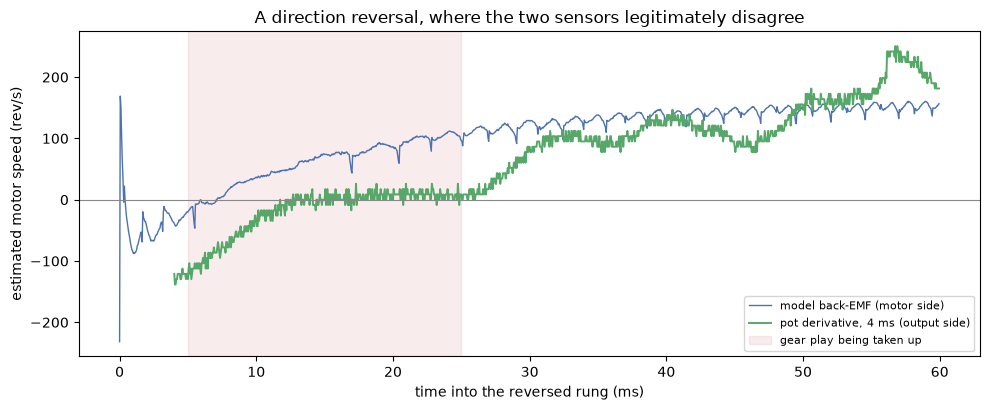

In [20]:
rv = ds.read("reversal", "capture-1", "sweep")
bias = rv[rv.cmd_duty_q15 == 0].current_raw.mean()
g = rv[rv.seg == 2].sort_values("tick")                # a 20% rung driven straight into reverse
sg = np.sign(int(g.cmd_duty_q15.iloc[0]))
i = (g.current_raw.values - bias) * board.a_per_count
v = board.diff_v(g.vmotor_a.values, g.vmotor_b.values) * sg
d = np.abs(g.duty_q15.values) / 32767
bemf = (d * v - R_WIND * i) / KE
p = g.pos.values.astype(float) * sg
W = 80
pot = np.full(len(p), np.nan); pot[W:] = (p[W:] - p[:-W]) / (W * DT) * POT_TO_REV
t = g.tick.values * DT * 1e3

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(t, bemf, color="#4c72b0", lw=1, label="model back-EMF (motor side)")
ax.plot(t, pot, color="#55a868", lw=1.4, label="pot derivative, 4 ms (output side)")
ax.axhline(0, color="#888", lw=0.8)
ax.axvspan(5, 25, color="#c44e52", alpha=0.10, label="gear play being taken up")
ax.set_xlabel("time into the reversed rung (ms)")
ax.set_ylabel("estimated motor speed (rev/s)")
ax.set_title("A direction reversal, where the two sensors legitimately disagree")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**What you are looking at:** the first 60 ms after the drive flips direction, estimated both
ways. The shaded strip is where notebook 06 measured the gear play being crossed, one to two
ripple cycles wide.

Inside that strip the back-EMF climbs from below zero up through 100 rev/s while the pot sits
flat. Neither is wrong. The motor really is turning and the output really is not, because the
teeth have not met yet. They are measurements of two different shafts with slop in between.

I cannot score this one against the ripple reference. The segments are 60 ms long and entirely
transient, and the ripple line needs a settled window, so this panel is a demonstration and not
a measurement. It matters anyway, because it means a fusion filter that treats the two as
measurements of the same state will fight itself every time the servo changes direction.

## The direct back-EMF reading

The fourth candidate. Turn the bridge fully off, let the terminals float, and with no current
there is no $R\,\bar i$ term to get wrong. This is the cleanest possible reading of speed, and
it is how $K_e$ was measured in the first place.

The catch is availability. It only exists in coast, and coast means not driving.

In [21]:
rowsd = []
for cap in ds.captures("bridge"):
    df = ds.read("bridge", cap, "spindown")
    segs = {s: gg.sort_values("tick") for s, gg in df.groupby("seg")}
    for s, gg in segs.items():
        duty = round(abs(int(gg.cmd_duty_q15.iloc[0])) / 32767 * 100)
        if duty not in (30, 40) or s + 1 not in segs:
            continue
        nxt = segs[s + 1]
        if int(nxt.cmd_duty_q15.iloc[0]) != 0:
            continue
        sg = np.sign(int(gg.dir.iloc[0]))
        vd = board.diff_v(nxt.vmotor_a.values, nxt.vmotor_b.values) * sg
        if vd[5] < 0.2:                                # brake, not coast: both terminals at 0
            continue
        # speed at the moment of release, from the last 40 ms of the drive that preceded it
        f_end = line_hz(gg.current_raw.values[-800:], nperseg=800)
        tt = np.arange(len(vd)) * DT
        m = (tt > 0.002) & (tt < 0.030) & (vd > 0.05)  # skip the bridge transition samples
        e0 = np.exp(np.polyfit(tt[m], np.log(vd[m]), 1)[1])
        rowsd.append(dict(capture=cap, duty=duty, drive_rev_s=f_end / PPR,
                          entry_v=e0, direct_rev_s=e0 / KE))
DB = pd.DataFrame(rowsd)
DB["err_pct"] = 100 * (DB.direct_rev_s / DB.drive_rev_s - 1)
print(DB.groupby("duty")[["drive_rev_s", "entry_v", "direct_rev_s", "err_pct"]]
        .agg(["mean", "std"]).round(2).to_string())
print(f"\npooled: {DB.err_pct.mean():+.1f}% against the end-of-drive ripple speed,"
      f" sd {DB.err_pct.std():.1f}%, n={len(DB)}")

     drive_rev_s       entry_v       direct_rev_s       err_pct      
            mean   std    mean   std         mean   std    mean   std
duty                                                                 
30        237.50  0.00    1.72  0.01       226.54  1.14   -4.61  0.48
40        326.46  2.17    2.37  0.03       312.55  3.32   -4.26  1.22

pooled: -4.4% against the end-of-drive ripple speed, sd 0.9%, n=20



The direct reading lands about four and a half percent below the drive speed with a spread
under a percent, and that gap grew when $K_e$ moved. On the old registry value it was 1.6
percent. The reading itself did not change, the constant it is divided by did, and this route
divides by $K_e$ with nothing else in the way, so it tracks the constant one for one.

That is uncomfortable, because $K_e$ was fitted on very nearly this measurement. A coast entry
voltage divided by a $K_e$ that came from coast entry voltages ought to reproduce the speed it
was fitted against, and it is out by four and a half percent against the drive-side ripple
line. Either the two speed references are not the same speed, or the fit and this readout are
not doing the same averaging. That goes in the open questions as question 5.

Look at what the reading costs, too. To take it the bridge has to stop driving, which means no
torque, and it has to stay off long enough for the winding current to die, which is a few tens
of microseconds. Then the reading decays as the shaft slows. As a runtime velocity source it is
a chopper that trades torque for measurement, and the model back-EMF gets a comparable answer
every single tick with the bridge still driving.

Where it earns its place is as a calibrator. It is the only route to $K_e$ that has no $R$ in
it at all, which is exactly why the registry value came from here.


## What the runtime should actually do

Ripple counting is out, and not by a small margin. Getting a frequency out of the current
channel here takes a 4096 point Welch spectrum, a band pass and a Hilbert transform. That is
an ident time instrument on a host, it is never firmware, and this notebook uses it only as
the ruler that the affordable estimators get measured against.

Of the rest:

- **Velocity comes from the model back-EMF**, $\hat\omega = (\bar v - R\,\bar i)/K_e$, with
  $\bar v$ from the crest terminal difference times duty and $\bar i$ from the crest current
  sample alone. Not the crest-trough average. One raw sample of it is already more than twice
  as quiet as 20 ms of pot differencing, it has no lag, and it lands within a percent and a
  half of the ripple reference.
- **A 1 ms boxcar on top** takes it from 2.3% scatter to 0.6% for 20 ticks of lag. Cheap and
  worth it.
- **Position comes from the pot, and velocity does not.** The corrected covariances give the
  pot about one part in eighteen thousand of the velocity weight, and the scatter it
  measurably has under drive gives it one part in two thousand. In the three state filter that
  means $L_2$, the gain from position innovation into the velocity state, should be small and
  the back-EMF should enter as its own velocity measurement rather than as a blend term at
  weight zero. Today it is the other way round, and that is the railing.
- **Do not try to fix the pot with a filter.** Its velocity error is 14.5% rms of deterministic
  position dependent gain against 2.2% of random noise. Averaging only helps against the second
  one. If a pot derived velocity is ever wanted it needs notebook 06's per position gain map,
  not a longer window.
- **If the pot is differenced at all, use a whole multiple of 4 ms.** More than half of the
  position channel's rest noise sits in a comb at multiples of 250 Hz, and a window that spans
  a whole number of those periods cancels it. That is a factor of two for free, and a window
  one tick off throws it away.
- **Gate on the sampling floor.** Below 13 percent duty the back-EMF estimate is not noisy, it
  is wrong, and it is confidently wrong in the negative direction. The `window_valid` flag
  already exists for this.
- **Track $R$.** A 40 degree warm up is a 16 percent resistance change, which invents about 48
  rev/s of motor speed at 30 percent duty while stalled. The velocity loop can live with that.
  A rest detector cannot.
- **Do not expect the two to agree through a reversal.** They are measuring opposite ends of a
  gear train with play in it, and during the crossing both are right.


## Caveats

Things that are true of this rig, or of this analysis, and should not be mistaken for facts
about the design.

- **One servo, one board.** $K_e$ is a per unit constant in this motor family, the parts
  listing and a measured can differ by a third. Nothing here transfers to another servo without
  re-measuring.
- **The board is a hand modified development board.** Notebook 07 measured a 1250 Hz tone in
  the current channel from the telemetry bus coupling into the sense amplifier. It sits inside
  the ripple search band. The commutation line is far taller so the peak pick still holds, but
  every current derived number here carries a systematic its standard deviation does not show.
  That matters more after the correction than before it, because the current channel is now the
  larger of the two terms in the back-EMF noise budget.
- **The reference band is narrow.** Everything scored here was driven between 30 and 45
  percent duty, because that is where the ripple line is trustworthy. The back-EMF estimate is
  unvalidated above 50 percent, where I have no independent reference at all.
- **The pot's scale is not a constant.** Notebook 06 measured its local gain swinging by a
  factor of 5.8 across the travel. The single counts per revolution figure used here is an
  average over the positions these rungs happened to cross, and the section above shows what
  that variation does to a pot derived speed.
- **The 4 ms rest noise figure is a best case.** It sits exactly on a null of the 250 Hz comb,
  and one tick either side of it the same measurement is about twice as large. Any weight
  computed from it inherits that.
- **The fusion weight assumes both inputs are unbiased.** Inverse variance weighting is only
  optimal when the errors are zero mean. The pot's error under drive is mostly not, and the
  back-EMF's error is not zero mean when $R$ has drifted. No weighting fixes either.
- **Every recording in these datasets opens with the shaft coasting.** The capture tool ran
  its rest burst after the post-rung brake and before the next seek, so both the noise baseline
  and every rung onset carry motion left over from the seek. `osc sweep` now takes
  `--settle-ms` with a default of 300 and brakes and holds after the seek, and the 2S and USB
  captures used here all predate that. Settled-window analysis is unaffected, and that is
  everything in this notebook downstream of the first 100 ms of a rung, which is the whole bake
  off, the fusion weights and the crossover. Onset-window analysis is affected, and that is the
  resistance section. **A recapture after the tool fix will not be comparable to these datasets
  for any onset quantity**, so do not pool the two.
- **What I checked for the same effect and found clean.** The per-capture current bias, which
  is a mean over the zero-duty baseline, moves by 0.03 counts out of 105 between the whole
  burst and the settled part, so the bias subtraction every current number here uses is
  untouched. The breakaway ladder's confident negative back-EMF reading at 1 to 4 percent duty
  is not the coast either, because splitting each 200 ms rung into its first fifteen percent
  and its last forty gives the same answer to within 0.15 rev/s, and a coast would decay. That
  reading is the sub-floor terminal sample, as the section says.
- **Two registry constants moved under this notebook while it was being written.** $K_e$ went
  from 7.367 to 7.584 mV per motor rev/s and the pot scale from 18.29 to 19.30 counts per
  degree, both from notebooks 03 and 06 being redone. Every number here that divides by $K_e$
  moved with it, which is the model back-EMF bias and the direct coast reading. The scatter
  figures did not move at all.


## Open questions, and what would settle them

For each one, what could cause it and the experiment that tells the causes apart. A cause with
no discriminating experiment is a story rather than a hypothesis, so where I only have a story
I say so.

**1. The six percent model back-EMF bias is closed.** Not a hypothesis any more. It was the
crest-trough current average halving the $R\,\bar i$ term, plus the spin-up transient inflating
the mean current in a whole-rung average. Each is worth six to nine percent on its own and
they push opposite ways, which is why the leftover looked like a subtle modelling problem
rather than two arithmetic errors. Fixing both puts the estimate within a percent and a half of
the reference with 1.1% scatter. The old explanation on the list, that the braked half is
modelled as zero volts when it reads 40 to 120 mV, is still true and still worth tens of
millivolts, but it was never big enough to be the answer. What is left is question 2.

**2. Most of the resistance duty slide is the onset coast, and a tenth of an ohm is not.**
The apparent resistance forced through the origin slides from 3.99 ohm at 70 to 100 percent
duty down to 3.64 at 30 percent. Fitting $V = i\,R + V_0$ instead gives R = 4.18 ohm and
$V_0 = -0.30$ V, and $R + V_0/i$ reproduces 85 percent of the slide. A fixed voltage divided by
a falling current is the right shape and the right sign, and the voltage is the seek coast
measured directly on the pre-drive terminals at -0.71 V.

That reverses one of the exclusions this question used to carry. I had ruled out a fixed
voltage term BY SIGN, on the grounds that it makes apparent resistance rise towards low duty.
That is true for a fixed voltage that is LOST, like a FET drop. This one is a back-EMF that
ASSISTS the drive, so its sign is the other way and it falls towards low duty, which is what
the ladder does.

*What is left.* The residual after the $V_0/i$ model is under 0.1 ohm of span, but it is not
flat. It arches, negative at both ends of the ladder and positive in the middle, against a
within-duty scatter of 0.03 to 0.09 ohm. So it is at the edge of being real.
*Causes:* $V_0$ is treated as one number for the whole ladder, and the coast decays during the
window, so a rung whose current settles faster sees a different average of it. Or the crest
current sample reads progressively high relative to the true period average as the on time
shortens, which was the surviving candidate before and still is.
*Discriminator:* the two predict different things about the window. Sweep the onset window
start and width and refit. A $V_0$ averaging effect changes with where the window sits, because
the coast is decaying underneath it, and it should shrink towards zero as the window is pushed
later. A crest sampling artefact does not care where the window is, only how short the on time
is. Both run on captures that already exist.

**3. The registry's two resistances stop disagreeing once the coast comes out, and $K_e$ takes
over the problem.** This one moved a long way. The free-intercept fit gives 4.18 +/- 0.02 ohm
in the assembled servo, and the registry's bare can figure is 4.20 [4.16, 4.24]. Those are the
same number. The old 3.99 was low because it was absorbing the seek coast, and the 13 percent
gap I was writing hypotheses about was mostly my own missing intercept.

What does not go away is notebook 03's 4.5 [4.3, 4.8] in-servo entry, which is still above
both, and the leftover bias in the model back-EMF. With $K_e$ at 7.584 the resistance that
would put the estimate exactly on the reference is about 3.6 ohm, which is below everything
measured, and adopting the free-fit 4.18 makes the bias more negative rather than less. So the
residual is now pointing at $K_e$ rather than at $R$.

*Causes:* $K_e$ carries the error, since it was fitted on coast entry voltages and question 5
shows that route disagreeing with the drive-side reference by four and a half percent. Or
notebook 03's 4.5 came off the previous sense chain, with a 33 mOhm shunt and ground-returned
dividers, and is not the same measurement as either of these. Or the model is missing a term
that looks like a scale error, the braked half being modelled as zero volts being the obvious
candidate.
*Discriminator:* $K_e$ and $R$ enter differently, so a wide speed sweep separates them. A wrong
$K_e$ is a pure scale error on speed. A wrong $R$ is an offset that grows with current. Score
the model against the ripple reference over as wide a speed range as the reference allows and
fit both at once. Separately, re-run notebook 03's exact onset procedure on these chain 3
captures WITH a free intercept, since if 03 forced through the origin it has the same bias I
had.

**4. Something puts a 250 Hz comb on the position channel.** More than half of the pot's
resting noise power sits in bins at multiples of 250 Hz, which is why a differencing window of
exactly 4 ms is twice as quiet as one a tick either side. This replaces the question that used
to be here, which was about the pot's noise not being white. That question was an artefact of
the contaminated baseline and it is dead.

*Causes:* the telemetry path, since notebook 07 tied the current channel's 1250 Hz tone to the
sixteen sample burst and 250 Hz is the rate at which something else in that path could repeat.
Or the ADC scan itself, if the position channel's sample sits at a fixed offset in a structure
that repeats every 80 ticks. Or the supply, if a switching regulator somewhere lands there.
*Discriminator:* change the telemetry burst cadence without touching the ADC scan and capture
the same baseline. If the comb moves with the burst rate it is the bus. If it does not, change
the scan length instead and see whether it follows that. If it follows neither, look at the
supply with a scope. All three are one capture each and no hardware.

**5. The direct coast reading sits four and a half percent under the drive speed.** It was 1.6
percent before $K_e$ moved, and this route is $e_0/K_e$ with nothing else in it, so it tracks
the constant directly.

*Causes:* the fit and this readout are not averaging the same thing, since $K_e$ was fitted on
very nearly this measurement and a small difference in how the drive speed was averaged shows
up here as an offset. Or the drive ripple average genuinely runs below the speed at release,
because the shaft is still accelerating through part of an 80 ms drive window. Or the two speed
references, coast entry and drive line, are measuring genuinely different speeds because the
gear train unloads at release.
*Discriminator:* measure the drive speed over the last 20 ms and again over the whole drive and
compare both against the same coast entry. If the offset tracks how much of the accelerating
part is included, it is the averaging window, and a spindown campaign with 250 ms drives
removes the question entirely. The third cause predicts something the other two do not, which
is that the offset should change with load, so repeat with a weight on the horn.

**6. The pot's velocity error is position locked, and I cannot yet say whether it is the pot or
the gear train.** This one moved a long way. It used to be phrased as the pot being four times
noisier under drive than at rest, with three candidates. It is now measured. The error is a
repeatable function of position, 14.5% rms at a 4 ms window, correlating at 0.997 between two
independent halves of the captures, and it accounts for essentially all of the pot's
under-drive scatter. Quantisation and backlash are ruled out above, by arithmetic and by
notebook 06's measurement respectively.

*Causes left:* the pot element's own local gain map, which notebook 06 measured directly and
which has the same 0.17 V period this residual shows. Or a mechanical speed ripple somewhere
between the motor and the wiper, which the motor side reference cannot see because any
torsional compliance sits between them.
*Discriminator:* notebook 06 already showed the pattern's period is about 33 per output
revolution while the three intermediate shafts turn 3.3, 13.1 and 49.9 times per output
revolution, which leans towards the pot. That is suggestive and not proof, because it assumes
the ripple would have to be at a shaft rate. The clean test needs a second angle sensor on the
output, which the IR encoder coupon would be, measuring the same rungs at the same time. If the
encoder sees the ripple, it is mechanical. If the encoder is smooth and only the pot wiggles,
it is the pot element and the gain map is the fix. A cheaper partial test is to load the horn
with a spring and repeat. Torsional compliance changes with load, a resistive track does not.

**7. CLOSED. The pot steps backwards at every rung onset because the shaft really is
coasting backwards.** Not a hypothesis any more, and it was closed from a channel I was not
looking at.

The mechanism is in the capture tool. `sweep.rs` ran its rest burst after the post-rung brake
and before the next seek, with nothing settling in between, so every rung opens with the shaft
still coasting from the seek. A forward rung's start band is the low guard, so the seek
approaches it travelling backwards. The step points backwards because the shaft is going
backwards, which is the one thing I used to rule real motion out.

Three independent channels see the same thing and they agree in sign and order. The pot slope
over the onset window reads -109 motor rev/s pooled. The pre-drive terminal difference, taken
with the bridge off and no current flowing, reads -0.708 V with a standard deviation of 0.067,
which is -93 motor rev/s through $K_e$ and cannot be anything except back-EMF. And it is flat
across every duty from 30 to 100 percent, which a seek-speed coast should be and an artefact
that scales with drive should not. A parallel analysis of the same captures put the entry EMF
at -0.70 V by three routes agreeing within 3 percent, so this is now four channels.

My other exclusion also has to go. I said the 80 ms spin-up made 125 rev/s impossible at 1.5 ms
in. That argument only holds for a shaft starting from rest and being accelerated by this rung.
It says nothing about a shaft that was already moving when the rung began.

*The residual is the interesting part.* Pooled, the pot side reads -109 rev/s and the terminal
side -93, a 17 percent gap. Split by direction it is not a gap at all, it is one direction.
Forward rungs start at the low guard and the two channels agree to 5 percent, -91.0 against
-96.1. Reverse rungs start at the high guard and the pot reads -127.0 against a terminal side
-90.6, which is 40 percent high. The terminal side is the same speed in both directions to
within 6 percent, which is what one seek doing the same thing twice should look like.

So the disagreement lives at one end of the travel and in one channel. That is the shape of
notebook 06's position dependent local gain, which swings 5.8x and which every forward rung
samples at one guard and every reverse rung at the other. The other candidates are that the two
measurements are not the same instant, since the terminal reading is the pre-drive sample and
the pot slope spans ticks 15 to 35 of a decaying coast, and that a 1 ms pot difference carries
about 70 rev/s of its own noise, which is 5 rev/s on a mean of 160 rungs and too small to
matter here.
*Discriminator:* read notebook 06's local gain map at the two guard positions and compare the
ratio of the two gains against the 1.40 and 0.95 measured here. If the map predicts them, the
residual is the pot and there is nothing else to find. If it does not, the seek is genuinely
faster in one direction and the terminal side should show that too, which it does not, so that
would be a real puzzle.

*Dataset consequence.* `osc sweep` now takes `--settle-ms`, default 300, and brakes and holds
after the seek. Every recording in the current 2S and USB datasets predates that, so they all
carry the coast, and a recapture after the fix will not be comparable to these for any onset
quantity. Settled-window work is unaffected either way.

**8. My pot scale is 2 percent under the registry's, and both were measured the same way.**
18.87 counts per degree here against 19.30 in the registry. The registry value is notebook 06's
travel weighted ripple cycle count, and it recently replaced an 18.29 that came from a Welch
peak route with a known +5.5% frequency bias. My calibration here should not have that bias,
because the ripple reference and the pot travel are both taken over the same settled window.

*Causes:* position weighting, since notebook 06 covers the whole travel and my rungs cover 0.74
to 2.52 wiper volts of it, and the local gain varies 5.8x underneath both. Or the Hilbert phase
derivative I use as a reference is not the same estimator as notebook 06's cycle count and
carries its own small bias.
*Discriminator:* run both estimators on the identical settled windows of the identical rungs
and compare them sample for sample, the way notebook 06 section 5.5 paired the two frequency
routes. If they agree there, the 2 percent is position weighting and the fix is the gain map
rather than a better single number. If they disagree, the Hilbert route needs characterising.


## Where this goes next

Notebook 09 wants the torque observer and the winding thermometer, and questions 2 and 3 above
land directly on both. The thermometer needs an $R$ measurement it can trust at whatever duty
the servo happens to be running, and right now the ladder only settles down above 70 percent.

The thing I would carry out of this one is not in the tables, and it is not the thing I thought
it would be when I started. The first version of this notebook found a six percent bias that
turned out to be two arithmetic errors, and I wrote at the bottom that the lesson was to plot a
channel against duty before putting it in a formula. That is still good advice. But then the
covariance table it was all weighted from turned out to have a shaft ringing down inside it,
and redoing this notebook against the corrected numbers moved the pot's weight in the opposite
direction from the one I would have bet on.

What actually saved it both times was the same thing. Somebody measured a control channel that
could not possibly carry the effect, and watched whether it moved. The trough current sample
carries no winding current, and plotting it against duty is what exposed the averaging error.
The current channel carries no mechanical term, and holding it still while the window changed
is what exposed the settling. Neither of those was a clever idea. They were both just a channel
that had no business responding, sitting in the same table as the ones that did.